In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Calibration from Market Data

Download Apple's data from Yahoo finance

In [2]:
# ==============================
# Settings
# ==============================
ticker = "AAPL"
start_date = "2021-01-01"
end_date = "2026-01-01"  # End date is excluded. Hence 2026-01-01 is used to include data up to 2025-12-31.

trading_days_per_year = 252
delta_t = 1 / trading_days_per_year

csv_filename = "AAPL_2021_2025.csv"


# ==============================
# Download Apple price data
# ==============================
apple = yf.Ticker(ticker)

data = apple.history(
    start=start_date,
    end=end_date,
    interval="1d",
    auto_adjust=True
)

if data.empty:
    raise ValueError(
        "No data were downloaded. Check the internet connection "
        "and the selected dates."
    )

# Keep the required columns
data = data[["Open", "High", "Low", "Close", "Volume"]].copy()

# Remove timezone information from the date index
if data.index.tz is not None:
    data.index = data.index.tz_localize(None)

# Sort observations by date
data = data.sort_index()

print("FIRST FIVE OBSERVATIONS")
print("-----------------------")
print(data.head())

print("\nLAST FIVE OBSERVATIONS")
print("----------------------")
print(data.tail())

print("\nNumber of trading days:", len(data))


# ==============================
# Save the downloaded data
# ==============================
data.to_csv(csv_filename)

print(f"\nData saved as {csv_filename}")

FIRST FIVE OBSERVATIONS
-----------------------
                  Open        High         Low       Close     Volume
Date                                                                 
2021-01-04  129.622544  129.709914  123.059867  125.632515  143301900
2021-01-05  125.127679  127.894493  124.681100  127.185791   97664900
2021-01-06  123.991828  127.224626  122.690939  122.904518  155088000
2021-01-07  124.613133  127.787685  124.127729  127.098404  109578200
2021-01-08  128.564332  128.758506  126.428554  128.195435  105158200

LAST FIVE OBSERVATIONS
----------------------
                  Open        High         Low       Close    Volume
Date                                                                
2025-12-24  271.600701  274.682309  271.461097  273.066711  17910600
2025-12-26  273.415814  274.622521  272.119325  272.657867  21521800
2025-12-29  271.949773  273.615223  271.610700  273.016876  23715200
2025-12-30  272.069428  273.335969  271.540868  272.338684  22139600
2

μ, σ, last historical price (initial simulation price)

In [3]:
# ==============================
# Read the data from the CSV file
# ==============================
data = pd.read_csv(
    csv_filename,
    index_col="Date",
    parse_dates=True
)

# Sort the data again after reading the CSV file
data = data.sort_index()


# ==============================
# Check data quality
# ==============================
print("\nDATA QUALITY CHECKS")
print("-------------------")

print("Missing values:")
print(data.isna().sum())

number_of_duplicates = data.index.duplicated().sum()

print("\nDuplicate dates:")
print(number_of_duplicates)

print("\nDate range:")
print(data.index.min().date(), "to", data.index.max().date())

# Stop the program if closing prices are missing
if data["Close"].isna().any():
    raise ValueError(
        "Missing closing prices were found. "
        "The data must be checked before estimating the parameters."
    )

# Stop the program if duplicate dates are found
if number_of_duplicates > 0:
    raise ValueError(
        "Duplicate dates were found. "
        "The data must be checked before estimating the parameters."
    )


# ==============================
# Calculate daily log returns
# ==============================
data["Log_Return"] = np.log(
    data["Close"] / data["Close"].shift(1)
)

# The first return is missing because S_0 has no previous price
returns = data["Log_Return"].dropna()


# ==============================
# Estimate model parameters
# ==============================

# Sample mean of daily log returns
mean_daily_log_return = returns.mean()

# Sample standard deviation of daily log returns
# ddof=1 gives the sample standard deviation
std_daily_log_return = returns.std(ddof=1)

# Annualised volatility:
# sigma_hat = Std(R_i) / sqrt(delta_t)
sigma_hat = std_daily_log_return / np.sqrt(delta_t)

# Annual drift:
# mu_hat = mean(R_i) / delta_t + 0.5 * sigma_hat^2
mu_hat = mean_daily_log_return / delta_t + 0.5 * sigma_hat**2

# The last observed historical price is S_n
S_n = data["Close"].iloc[-1]

# S_n becomes the initial value of the simulated process
S0_sim = S_n


# ==============================
# Display parameter estimates
# ==============================
print("\nBLACK-SCHOLES PARAMETER ESTIMATION")
print("----------------------------------")

print(f"Ticker: {ticker}")
print(
    f"First available date: "
    f"{data.index.min().date()}"
)
print(
    f"Last available date: "
    f"{data.index.max().date()}"
)

print(
    f"Number of price observations: "
    f"{len(data)}"
)
print(
    f"Number of return observations: "
    f"{len(returns)}"
)

print("\nDAILY LOG-RETURN STATISTICS")
print("---------------------------")

print(
    f"Mean daily log return: "
    f"{mean_daily_log_return:.8f}"
)

print(
    f"Sample standard deviation: "
    f"{std_daily_log_return:.8f}"
)

print("\nANNUALISED PARAMETER ESTIMATES")
print("------------------------------")

print(
    f"Estimated volatility (sigma_hat): "
    f"{sigma_hat:.6f}"
)

print(
    f"Estimated volatility: "
    f"{sigma_hat:.2%}"
)

print(
    f"Estimated drift (mu_hat): "
    f"{mu_hat:.6f}"
)

print(
    f"Estimated drift: "
    f"{mu_hat:.2%}"
)

print(
    f"Last observed historical price (S_n): "
    f"{S_n:.4f}"
)

print(
    f"Initial price for simulation (S0_sim): "
    f"{S0_sim:.4f}"
)


# ==============================
# Save the processed data
# ==============================
processed_filename = "AAPL_2021_2025_processed.csv"

data.to_csv(processed_filename)

print(
    f"\nProcessed data saved as "
    f"{processed_filename}"
)


DATA QUALITY CHECKS
-------------------
Missing values:
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Duplicate dates:
0

Date range:
2021-01-04 to 2025-12-31

BLACK-SCHOLES PARAMETER ESTIMATION
----------------------------------
Ticker: AAPL
First available date: 2021-01-04
Last available date: 2025-12-31
Number of price observations: 1255
Number of return observations: 1254

DAILY LOG-RETURN STATISTICS
---------------------------
Mean daily log return: 0.00061340
Sample standard deviation: 0.01749005

ANNUALISED PARAMETER ESTIMATES
------------------------------
Estimated volatility (sigma_hat): 0.277646
Estimated volatility: 27.76%
Estimated drift (mu_hat): 0.193121
Estimated drift: 19.31%
Last observed historical price (S_n): 271.1220
Initial price for simulation (S0_sim): 271.1220

Processed data saved as AAPL_2021_2025_processed.csv


Plot historical price and log returns

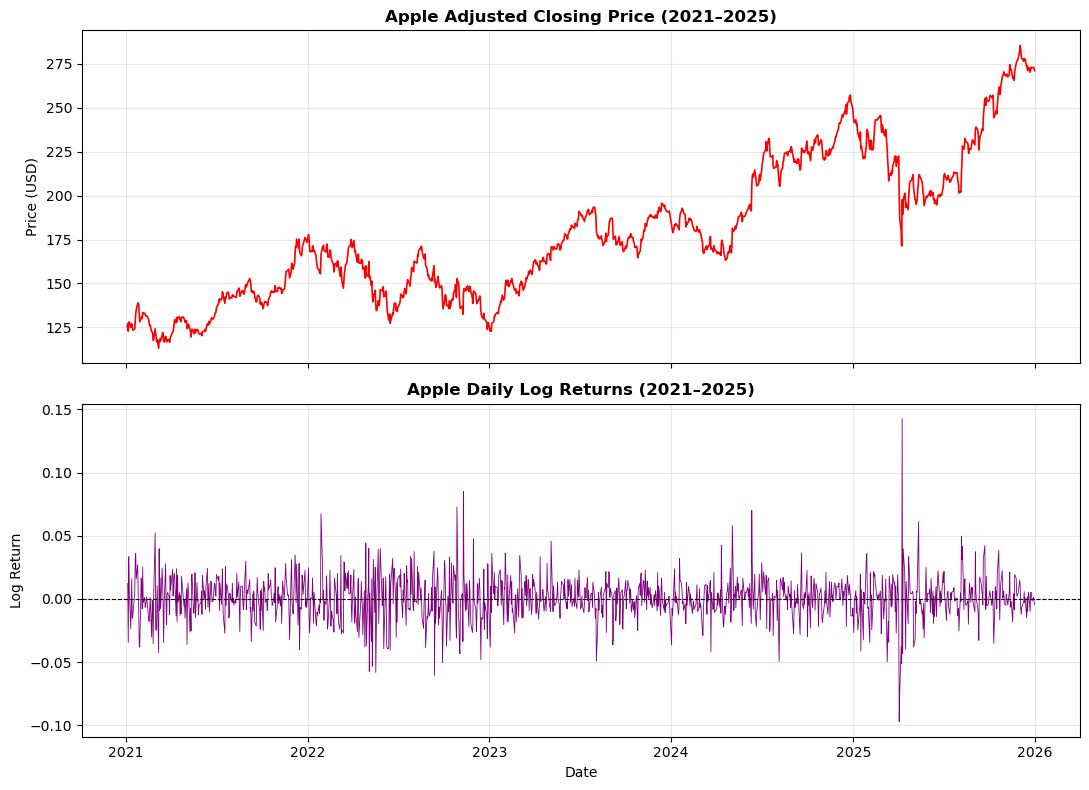

Figure saved as AAPL_price_and_log_returns.png


In [4]:
# ==============================
# Plot historical price and log returns
# ==============================
fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 8),
    sharex=True
)

# Adjusted closing price
axes[0].plot(
    data.index,
    data["Close"],
    color="red",
    linewidth=1.2
)

axes[0].set_title(
    "Apple Adjusted Closing Price (2021–2025)",
    fontweight="bold"
)
axes[0].set_ylabel("Price (USD)")
axes[0].grid(
    alpha=0.3
)

# Daily log returns
axes[1].plot(
    data.index,
    data["Log_Return"],
    color="purple",
    linewidth=0.6
)

axes[1].axhline(
    y=0,
    color="black",
    linewidth=0.8,
    linestyle="--"
)

axes[1].set_title(
    "Apple Daily Log Returns (2021–2025)",
    fontweight="bold"
)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Log Return")
axes[1].grid(
    alpha=0.3
)

fig.tight_layout()

# Save before plt.show()
figure_filename = "AAPL_price_and_log_returns.png"

fig.savefig(
    figure_filename,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved as {figure_filename}")

# Step 2: Simulation of Brownian Motion

Simulate future stock prices for 1 year

In [5]:
# ==============================
# Simulate future stock prices
# ==============================

# Simulation settings
T = 1
N = 252
delta_t_sim = T / N

number_of_paths = 10000


# Fix the random seed so that the results can be reproduced
random_seed = 42
rng = np.random.default_rng(random_seed)

# Simulation time points
time_grid = np.linspace(
    0,
    T,
    N + 1
)

# Generate independent standard normal variables
Z = rng.standard_normal(
    size=(N, number_of_paths)
)

# Daily continuously compounded stock returns
simulated_log_returns = (
    (mu_hat - 0.5 * sigma_hat**2) * delta_t_sim
    + sigma_hat * np.sqrt(delta_t_sim) * Z
)

# Create the simulated stock price array
simulated_prices = np.empty(
    (N + 1, number_of_paths)
)

# All paths start from the last observed historical price
simulated_prices[0, :] = S0_sim

# Construct each path using cumulative log returns
simulated_prices[1:, :] = (
    S0_sim
    * np.exp(
        np.cumsum(
            simulated_log_returns,
            axis=0
        )
    )
)

# Retain terminal stock prices
terminal_prices = simulated_prices[-1, :]


# ==============================
# Summary of simulation results
# ==============================

mean_terminal_price = terminal_prices.mean()
median_terminal_price = np.median(terminal_prices)
std_terminal_price = terminal_prices.std(ddof=1)

lower_terminal_price = np.percentile(
    terminal_prices,
    2.5
)

upper_terminal_price = np.percentile(
    terminal_prices,
    97.5
)

print("\nSTOCK PRICE SIMULATION")
print("----------------------")

print(f"Simulation horizon: {T} year")
print(f"Number of time steps: {N}")
print(f"Number of simulated paths: {number_of_paths}")
print(f"Random seed: {random_seed}")

print(
    f"\nInitial simulated price: "
    f"{S0_sim:.4f}"
)

print(
    f"Mean terminal price: "
    f"{mean_terminal_price:.4f}"
)

print(
    f"Median terminal price: "
    f"{median_terminal_price:.4f}"
)

print(
    f"Standard deviation of terminal prices: "
    f"{std_terminal_price:.4f}"
)

print(
    f"2.5th percentile: "
    f"{lower_terminal_price:.4f}"
)

print(
    f"97.5th percentile: "
    f"{upper_terminal_price:.4f}"
)





STOCK PRICE SIMULATION
----------------------
Simulation horizon: 1 year
Number of time steps: 252
Number of simulated paths: 10000
Random seed: 42

Initial simulated price: 271.1220
Mean terminal price: 329.7583
Median terminal price: 316.8069
Standard deviation of terminal prices: 93.5725
2.5th percentile: 182.5376
97.5th percentile: 547.7230


Plot first 20 paths of simulation prices

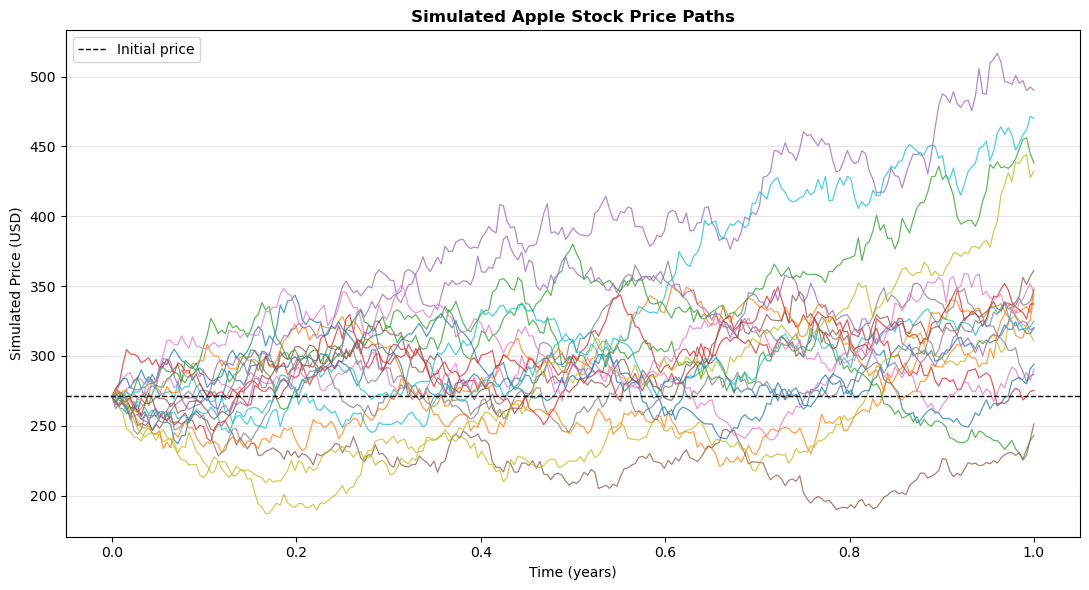


Simulation figure saved as AAPL_simulated_price_paths.png


In [6]:
# ==============================
# Plot selected simulated paths
# ==============================

number_of_displayed_paths = 20
fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.plot(
    time_grid,
    simulated_prices[
        :,
        :number_of_displayed_paths
    ],
    linewidth=0.9,
    alpha=0.75
)

ax.axhline(
    y=S0_sim,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Initial price"
)

ax.set_title(
    "Simulated Apple Stock Price Paths",
    fontweight="bold"
)

ax.set_xlabel("Time (years)")
ax.set_ylabel("Simulated Price (USD)")

ax.grid(
    axis="y",
    alpha=0.3
)

ax.legend()

fig.tight_layout()

simulation_figure_filename = (
    "AAPL_simulated_price_paths.png"
)

fig.savefig(
    simulation_figure_filename,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\nSimulation figure saved as "
    f"{simulation_figure_filename}"
)

# Step 3: Enlargement of Filtration

construct noisy imformation

In [7]:
# ==========================================
# Construction of noisy insider information
# ==========================================

# Recover the terminal Brownian motion values
# from the same standard normal variables used
# to simulate the stock price paths
terminal_brownian_values = (
    np.sqrt(delta_t_sim)
    * np.sum(Z, axis=0)
)

# Noise levels considered in the experiment
noise_levels = np.array([
    0.05,
    0.10,
    0.25,
    0.50,
    1.00
])

# Use a separate random number generator
# for the independent signal noise
noise_random_seed = 2026

noise_rng = np.random.default_rng(
    noise_random_seed
)

# Generate one independent standard normal
# noise variable for each simulated path
xi = noise_rng.standard_normal(
    number_of_paths
)

# Store the noisy signals for all noise levels
noisy_signals = {}

# Store the summary statistics and
# analytical benchmark values
signal_results = []


# ==========================================
# Summary of terminal Brownian motion
# ==========================================

print("\nTERMINAL BROWNIAN MOTION")
print("------------------------")

print(
    f"Sample mean of W_T: "
    f"{terminal_brownian_values.mean():.4f}"
)

print(
    f"Sample variance of W_T: "
    f"{terminal_brownian_values.var(ddof=1):.4f}"
)


# ==========================================
# Construct the noisy signals
# ==========================================

for epsilon in noise_levels:

    # Noisy insider signal:
    # G_epsilon = W_T + epsilon * xi
    signal = (
        terminal_brownian_values
        + epsilon * xi
    )

    # Store the complete signal array
    # for the current noise level
    noisy_signals[epsilon] = signal

    # --------------------------------------
    # Monte Carlo sample statistics
    # --------------------------------------

    sample_mean = signal.mean()

    sample_variance = signal.var(
        ddof=1
    )

    sample_correlation = np.corrcoef(
        signal,
        terminal_brownian_values
    )[0, 1]

    # --------------------------------------
    # Analytical benchmarks implied by
    # the noisy-signal specification
    # --------------------------------------

    # E[G_epsilon] = 0
    analytical_benchmark_mean = 0.0

    # Var(G_epsilon) = T + epsilon^2
    analytical_benchmark_variance = (
        T + epsilon**2
    )

    # Corr(G_epsilon, W_T)
    # = sqrt(T / (T + epsilon^2))
    analytical_benchmark_correlation = np.sqrt(
        T / (T + epsilon**2)
    )

    # Store the results for the current
    # noise level
    signal_results.append({
        "Noise level": epsilon,
        "Analytical benchmark mean":
            analytical_benchmark_mean,
        "Sample mean":
            sample_mean,
        "Analytical benchmark variance":
            analytical_benchmark_variance,
        "Sample variance":
            sample_variance,
        "Analytical benchmark correlation":
            analytical_benchmark_correlation,
        "Sample correlation":
            sample_correlation
    })


# ==========================================
# Convert the results into a table
# ==========================================

signal_results_df = pd.DataFrame(
    signal_results
)

print("\nNOISY SIGNAL RESULTS")
print("--------------------")

print(
    signal_results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)





TERMINAL BROWNIAN MOTION
------------------------
Sample mean of W_T: 0.0088
Sample variance of W_T: 1.0064

NOISY SIGNAL RESULTS
--------------------
 Noise level  Analytical benchmark mean  Sample mean  Analytical benchmark variance  Sample variance  Analytical benchmark correlation  Sample correlation
      0.0500                     0.0000       0.0087                         1.0025           1.0096                            0.9988              0.9987
      0.1000                     0.0000       0.0086                         1.0100           1.0178                            0.9950              0.9950
      0.2500                     0.0000       0.0083                         1.0625           1.0727                            0.9701              0.9701
      0.5000                     0.0000       0.0078                         1.2500           1.2654                            0.8944              0.8945
      1.0000                     0.0000       0.0067                     

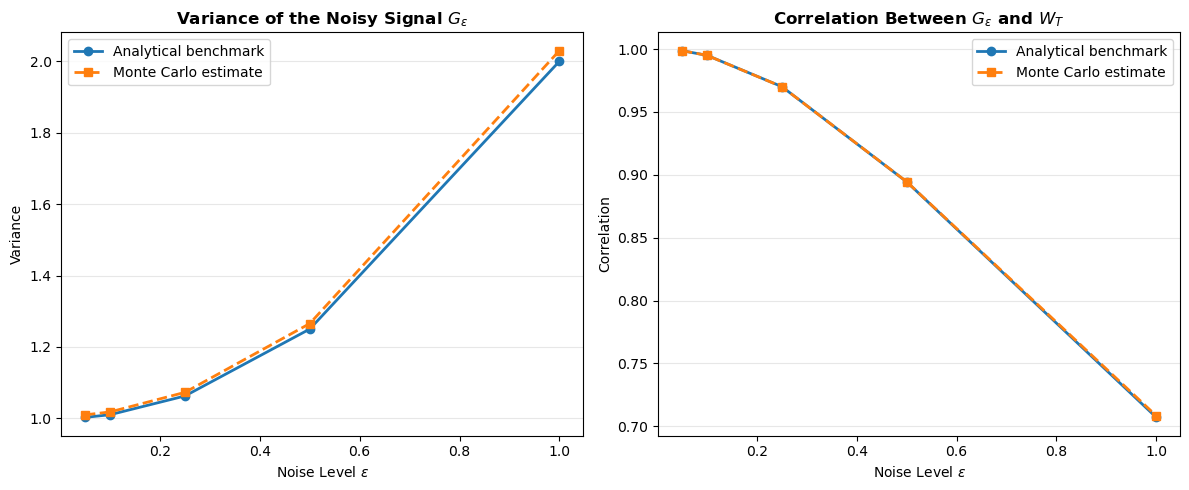


Noisy signal figure saved as AAPL_noisy_signal_comparison.png


In [8]:
# ==========================================
# Plot analytical benchmarks and Monte Carlo estimates
# ==========================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)


# ==========================================
# Variance comparison
# ==========================================

axes[0].plot(
    noise_levels,
    signal_results_df[
        "Analytical benchmark variance"
    ],
    marker="o",
    linewidth=2,
    label="Analytical benchmark"
)

axes[0].plot(
    noise_levels,
    signal_results_df[
        "Sample variance"
    ],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Monte Carlo estimate"
)

axes[0].set_title(
    r"Variance of the Noisy Signal $G_\varepsilon$",
    fontweight="bold"
)

axes[0].set_xlabel(
    r"Noise Level $\varepsilon$"
)

axes[0].set_ylabel(
    "Variance"
)

axes[0].grid(
    axis="y",
    alpha=0.3
)

axes[0].legend()


# ==========================================
# Correlation comparison
# ==========================================

axes[1].plot(
    noise_levels,
    signal_results_df[
        "Analytical benchmark correlation"
    ],
    marker="o",
    linewidth=2,
    label="Analytical benchmark"
)

axes[1].plot(
    noise_levels,
    signal_results_df[
        "Sample correlation"
    ],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Monte Carlo estimate"
)

axes[1].set_title(
    r"Correlation Between $G_\varepsilon$ and $W_T$",
    fontweight="bold"
)

axes[1].set_xlabel(
    r"Noise Level $\varepsilon$"
)

axes[1].set_ylabel(
    "Correlation"
)

axes[1].grid(
    axis="y",
    alpha=0.3
)

axes[1].legend()


# ==========================================
# Save and display the figure
# ==========================================

fig.tight_layout()

signal_figure_filename = (
    "AAPL_noisy_signal_comparison.png"
)

fig.savefig(
    signal_figure_filename,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\nNoisy signal figure saved as "
    f"{signal_figure_filename}"
)

# Step 4: Estimation of Conditional Expectations

In [9]:
# Construct Brownian motion paths from the same Z
# used in the stock price simulation
brownian_paths = np.zeros(
    (N + 1, number_of_paths)
)

brownian_paths[1:, :] = np.cumsum(
    np.sqrt(delta_t_sim) * Z,
    axis=0
)

terminal_brownian_values = brownian_paths[-1, :]

In [10]:
# ==================================================
# Monte Carlo regression with a training-testing split
# ==================================================

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


# Each index represents one complete
# Monte Carlo path
path_indices = np.arange(
    number_of_paths
)

# Split complete paths into training and
# testing samples
#
# The same split is used for all observation
# times and all noise levels
training_indices, testing_indices = train_test_split(
    path_indices,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print("\nMONTE CARLO SAMPLE SPLIT")
print("------------------------")

print(
    f"Training paths: "
    f"{len(training_indices)}"
)

print(
    f"Testing paths: "
    f"{len(testing_indices)}"
)


# ==================================================
# Create containers for the results
# ==================================================

# Store the conditional expectation estimates
# obtained from Monte Carlo regression
conditional_expectation_estimates = {}

# Store the conditional expectations calculated
# directly from the analytical expression
analytical_conditional_expectations = {}

# Store estimated coefficients, analytical
# benchmark coefficients and regression diagnostics
regression_results = []


# ==================================================
# Estimate the conditional expectations
# ==================================================

for epsilon in noise_levels:

    # Noisy insider signal:
    # G_epsilon = W_T + epsilon * xi
    signal = noisy_signals[epsilon]

    # Store regression estimates for all time
    # points and all Monte Carlo paths
    estimated_m = np.empty(
        (N + 1, number_of_paths)
    )

    # Store the analytical conditional expectation
    # benchmarks for all time points and paths
    analytical_m = np.empty(
        (N + 1, number_of_paths)
    )

    # Perform one cross-sectional regression
    # at each observation time before maturity
    for time_index, t in enumerate(
        time_grid[:-1]
    ):

        # Brownian values W_t across all paths
        # at the current observation time
        current_brownian_values = (
            brownian_paths[time_index, :]
        )

        # Response variable:
        # terminal Brownian value W_T
        regression_target = (
            terminal_brownian_values
        )

        # ------------------------------------------
        # Construct the regression inputs
        # ------------------------------------------

        if time_index == 0:

            # At t = 0, W_0 is identically zero.
            # Its coefficient cannot be separately
            # identified, so W_0 is omitted.
            #
            # The only explanatory variable is
            # the noisy signal G_epsilon.
            regression_inputs = signal.reshape(
                -1,
                1
            )

        else:

            # At t > 0, the explanatory variables
            # are W_t and G_epsilon.
            regression_inputs = np.column_stack(
                (
                    current_brownian_values,
                    signal
                )
            )

        # ------------------------------------------
        # Fit the Monte Carlo regression
        # ------------------------------------------

        model = LinearRegression()

        # Fit the model using only the
        # training paths
        model.fit(
            regression_inputs[training_indices],
            regression_target[training_indices]
        )

        # Calculate the fitted conditional mean
        # for all Monte Carlo paths
        estimated_m[time_index, :] = model.predict(
            regression_inputs
        )

        # ------------------------------------------
        # Analytical conditional expectation
        # ------------------------------------------

        # Weight placed on the additional signal
        signal_weight = (
            (T - t)
            / (T - t + epsilon**2)
        )

        # Analytical benchmark:
        #
        # m_t = W_t
        #       + signal_weight * (G_epsilon - W_t)
        analytical_m[time_index, :] = (
            current_brownian_values
            + signal_weight
            * (
                signal
                - current_brownian_values
            )
        )

        # ------------------------------------------
        # Estimated and analytical coefficients
        # ------------------------------------------

        if time_index == 0:

            # W_0 is omitted because it is
            # identically zero. Its coefficient
            # is therefore not identifiable.
            estimated_coefficient_W = np.nan

            analytical_benchmark_coefficient_W = (
                np.nan
            )

            # Since G_epsilon is the only regressor,
            # its coefficient is the first element.
            estimated_coefficient_G = (
                model.coef_[0]
            )

        else:

            # For t > 0, the first coefficient is
            # attached to W_t and the second is
            # attached to G_epsilon.
            estimated_coefficient_W = (
                model.coef_[0]
            )

            estimated_coefficient_G = (
                model.coef_[1]
            )

            # Analytical benchmark coefficient on W_t:
            #
            # epsilon^2 / (T - t + epsilon^2)
            analytical_benchmark_coefficient_W = (
                epsilon**2
                / (T - t + epsilon**2)
            )

        # Analytical benchmark coefficient
        # on G_epsilon:
        #
        # (T - t) / (T - t + epsilon^2)
        analytical_benchmark_coefficient_G = (
            (T - t)
            / (T - t + epsilon**2)
        )

        # ------------------------------------------
        # Regression diagnostics
        # ------------------------------------------

        # R-squared calculated on the
        # training paths
        training_r_squared = model.score(
            regression_inputs[training_indices],
            regression_target[training_indices]
        )

        # R-squared calculated on the
        # held-out testing paths
        testing_r_squared = model.score(
            regression_inputs[testing_indices],
            regression_target[testing_indices]
        )

        # ------------------------------------------
        # Store the results
        # ------------------------------------------

        regression_results.append({
            "Time":
                t,
            "Noise level":
                epsilon,
            "Estimated intercept":
                model.intercept_,
            "Estimated coefficient on W_t":
                estimated_coefficient_W,
            "Analytical benchmark coefficient on W_t":
                analytical_benchmark_coefficient_W,
            "Estimated coefficient on G_epsilon":
                estimated_coefficient_G,
            "Analytical benchmark coefficient on G_epsilon":
                analytical_benchmark_coefficient_G,
            "Training R-squared":
                training_r_squared,
            "Testing R-squared":
                testing_r_squared
        })

    # ----------------------------------------------
    # Conditional expectation at maturity
    # ----------------------------------------------

    # At t = T, W_T has already been observed.
    # No regression is required.
    estimated_m[-1, :] = (
        terminal_brownian_values
    )

    analytical_m[-1, :] = (
        terminal_brownian_values
    )

    # Store all conditional expectation estimates
    # for the current noise level
    conditional_expectation_estimates[
        epsilon
    ] = estimated_m

    # Store all analytical conditional
    # expectations for the current noise level
    analytical_conditional_expectations[
        epsilon
    ] = analytical_m


# ==================================================
# Convert the regression results into a table
# ==================================================

regression_results_df = pd.DataFrame(
    regression_results
)


MONTE CARLO SAMPLE SPLIT
------------------------
Training paths: 8000
Testing paths: 2000


输出选定时刻的回归结果

In [11]:
# ==================================================
# Display results at selected times
# ==================================================

selected_time_indices = [
    0,
    int(0.25 * N),
    int(0.50 * N),
    int(0.75 * N)
]

selected_times = time_grid[
    selected_time_indices
]

selected_regression_results = (
    regression_results_df[
        np.isclose(
            regression_results_df["Time"].to_numpy()[:, None],
            selected_times,
            atol=1e-10
        ).any(axis=1)
    ]
    .copy()
)

print("\nSELECTED REGRESSION RESULTS")
print("---------------------------")

print(
    selected_regression_results.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


SELECTED REGRESSION RESULTS
---------------------------
  Time  Noise level  Estimated intercept  Estimated coefficient on W_t  Analytical benchmark coefficient on W_t  Estimated coefficient on G_epsilon  Analytical benchmark coefficient on G_epsilon  Training R-squared  Testing R-squared
0.0000       0.0500               0.0004                           NaN                                      NaN                              0.9969                                         0.9975              0.9975             0.9975
0.2500       0.0500               0.0004                        0.0030                                   0.0033                              0.9961                                         0.9967              0.9975             0.9975
0.5000       0.0500               0.0004                        0.0042                                   0.0050                              0.9948                                         0.9950              0.9975             0.9975
0.7500 

在 testing sample 上进行验证

In [12]:
# ==================================================
# Validation on testing paths
# ==================================================

# Store validation results calculated using
# paths that were not used to fit the regressions
validation_results = []

for epsilon in noise_levels:

    # Conditional expectations estimated by
    # Monte Carlo regression
    estimated_m = (
        conditional_expectation_estimates[
            epsilon
        ]
    )

    # Conditional expectations calculated from
    # the analytical expression
    analytical_m = (
        analytical_conditional_expectations[
            epsilon
        ]
    )

    # Evaluate the predictions at the
    # selected observation times
    for time_index in selected_time_indices:

        t = time_grid[time_index]

        # Regression estimates on the
        # testing paths
        regression_test_values = (
            estimated_m[
                time_index,
                testing_indices
            ]
        )

        # Analytical conditional expectation
        # benchmarks on the testing paths
        analytical_test_values = (
            analytical_m[
                time_index,
                testing_indices
            ]
        )

        # Terminal Brownian values W_T on the
        # testing paths
        terminal_test_values = (
            terminal_brownian_values[
                testing_indices
            ]
        )

        # Current Brownian values W_t on the
        # testing paths
        current_test_values = (
            brownian_paths[
                time_index,
                testing_indices
            ]
        )

        # ------------------------------------------
        # Regression approximation error
        # ------------------------------------------

        # RMSE between the Monte Carlo regression
        # estimates and the analytical conditional
        # expectation benchmarks
        regression_benchmark_rmse = np.sqrt(
            np.mean(
                (
                    regression_test_values
                    - analytical_test_values
                ) ** 2
            )
        )

        # ------------------------------------------
        # Insider prediction error
        # ------------------------------------------

        # The insider uses the regression estimate
        # of E[W_T | W_t, G_epsilon] to predict W_T
        insider_terminal_rmse = np.sqrt(
            np.mean(
                (
                    regression_test_values
                    - terminal_test_values
                ) ** 2
            )
        )

        # ------------------------------------------
        # Ordinary investor prediction error
        # ------------------------------------------

        # Under the reference filtration, the
        # ordinary investor uses W_t to predict W_T
        ordinary_terminal_rmse = np.sqrt(
            np.mean(
                (
                    current_test_values
                    - terminal_test_values
                ) ** 2
            )
        )

        # ------------------------------------------
        # Relative reduction in prediction error
        # ------------------------------------------

        rmse_reduction = (
            1
            - insider_terminal_rmse
            / ordinary_terminal_rmse
        ) * 100

        # Store the validation results for the
        # current time and noise level
        validation_results.append({
            "Noise level":
                epsilon,
            "Time":
                t,
            "Regression vs analytical benchmark RMSE":
                regression_benchmark_rmse,
            "Ordinary investor testing RMSE":
                ordinary_terminal_rmse,
            "Insider testing RMSE":
                insider_terminal_rmse,
            "RMSE reduction (%)":
                rmse_reduction
        })


# Convert the validation results into a table
validation_results_df = pd.DataFrame(
    validation_results
)

print("\nVALIDATION RESULTS ON TESTING PATHS")
print("-----------------------------------")

print(
    validation_results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


VALIDATION RESULTS ON TESTING PATHS
-----------------------------------
 Noise level   Time  Regression vs analytical benchmark RMSE  Ordinary investor testing RMSE  Insider testing RMSE  RMSE reduction (%)
      0.0500 0.0000                                   0.0007                          0.9982                0.0500             94.9894
      0.0500 0.2500                                   0.0007                          0.8700                0.0500             94.2475
      0.0500 0.5000                                   0.0008                          0.7078                0.0499             92.9437
      0.0500 0.7500                                   0.0008                          0.5028                0.0498             90.0953
      0.1000 0.0000                                   0.0014                          0.9982                0.0997             90.0077
      0.1000 0.2500                                   0.0016                          0.8700                0.0998   

绘制 testing path 的条件期望轨迹

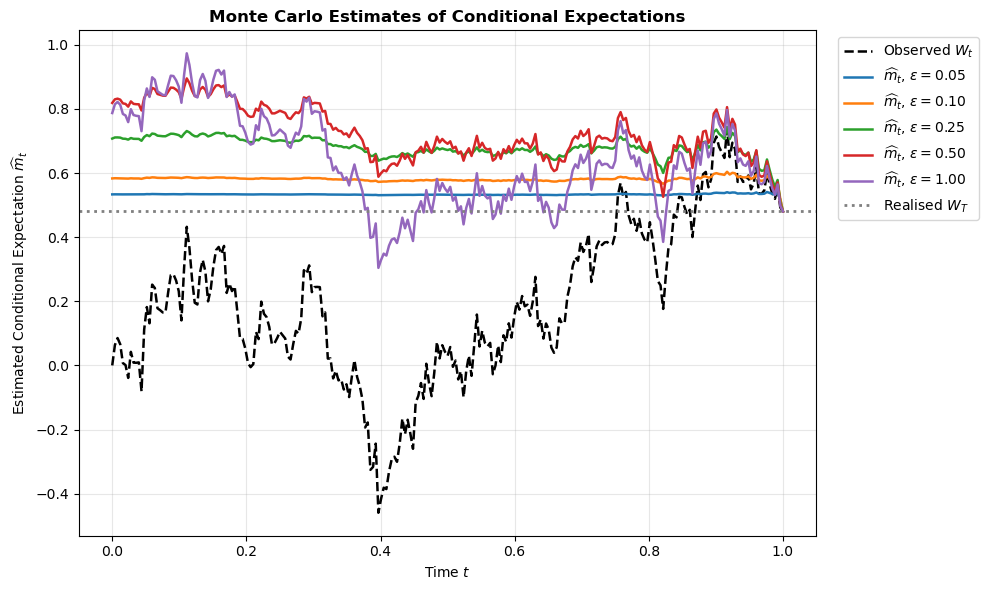


Conditional expectation figure saved as monte_carlo_conditional_expectations.png


In [13]:
# ==================================================
# Plot Monte Carlo conditional expectation estimates
# ==================================================

# Select one path from the testing sample
selected_testing_path = testing_indices[0]

fig, ax = plt.subplots(
    figsize=(10, 6)
)

# Brownian motion observed over time
ax.plot(
    time_grid,
    brownian_paths[:, selected_testing_path],
    color="black",
    linestyle="--",
    linewidth=1.8,
    label=r"Observed $W_t$"
)

# Estimated conditional expectations for
# different noise levels
for epsilon in noise_levels:

    ax.plot(
        time_grid,
        conditional_expectation_estimates[
            epsilon
        ][:, selected_testing_path],
        linewidth=1.8,
        label=(
            rf"$\widehat{{m}}_t$, "
            rf"$\varepsilon={epsilon:.2f}$"
        )
    )

# Realised terminal Brownian value for
# the selected testing path
ax.axhline(
    terminal_brownian_values[
        selected_testing_path
    ],
    color="grey",
    linestyle=":",
    linewidth=2,
    label=r"Realised $W_T$"
)

ax.set_title(
    "Monte Carlo Estimates of Conditional Expectations",
    fontweight="bold"
)

ax.set_xlabel(
    r"Time $t$"
)

ax.set_ylabel(
    r"Estimated Conditional Expectation "
    r"$\widehat{m}_t$"
)

ax.grid(
    alpha=0.3
)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

fig.tight_layout()

conditional_expectation_filename = (
    "monte_carlo_conditional_expectations.png"
)

fig.savefig(
    conditional_expectation_filename,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\nConditional expectation figure saved as "
    f"{conditional_expectation_filename}"
)

# Step 5: Computation of the Information Drift

In [16]:
# ==================================================
# Estimation of the information drift
# ==================================================

# The information drift is calculated only for t < T.
# The maturity time t = T is excluded because
# (m_T - W_T) / (T - T) would have the form 0 / 0.
drift_time_grid = time_grid[:-1]

# Remaining time to maturity at each
# drift observation time
remaining_time = (
    T - drift_time_grid
)


# ==================================================
# Define the near-maturity region
# ==================================================

# The near-maturity region is [0.9T, T)
near_maturity_start = 0.90 * T

near_maturity_mask = (
    drift_time_grid >= near_maturity_start
)

near_maturity_indices = np.where(
    near_maturity_mask
)[0]


# ==================================================
# Create containers for the results
# ==================================================

# Store the pathwise information drift estimates
# obtained from Monte Carlo regression
estimated_information_drifts = {}

# Store the pathwise information drifts calculated
# from the analytical expression
analytical_information_drifts = {}

# Store time-dependent summary statistics
information_drift_results = []


# ==================================================
# Calculate the information drift
# ==================================================

for epsilon in noise_levels:

    # Regression-based conditional expectation
    # estimates for the current noise level
    estimated_m = (
        conditional_expectation_estimates[
            epsilon
        ]
    )

    # Conditional expectations calculated from
    # the analytical expression
    analytical_m = (
        analytical_conditional_expectations[
            epsilon
        ]
    )

    # ----------------------------------------------
    # Select testing paths and exclude maturity
    # ----------------------------------------------

    # Regression-based conditional expectation
    # estimates on the testing paths
    estimated_m_test = estimated_m[
        :-1,
        testing_indices
    ]

    # Analytical conditional expectations
    # on the same testing paths
    analytical_m_test = analytical_m[
        :-1,
        testing_indices
    ]

    # Brownian values W_t on the testing paths
    brownian_test = brownian_paths[
        :-1,
        testing_indices
    ]

    # Noisy signals G_epsilon on the testing paths
    signal_test = noisy_signals[
        epsilon
    ][testing_indices]

    # ----------------------------------------------
    # Regression-based information drift estimate
    # ----------------------------------------------

    # Estimated information drift:
    #
    # alpha_hat_t
    # = (m_hat_t - W_t) / (T - t)
    estimated_alpha = (
        estimated_m_test
        - brownian_test
    ) / remaining_time[:, None]

    # ----------------------------------------------
    # Analytical information drift
    # ----------------------------------------------

    # Analytical information drift calculated
    # from the analytical conditional expectation:
    #
    # alpha_t
    # = (m_t - W_t) / (T - t)
    analytical_alpha = (
        analytical_m_test
        - brownian_test
    ) / remaining_time[:, None]

    # The same analytical drift calculated directly:
    #
    # alpha_t
    # = (G_epsilon - W_t)
    #   / (T - t + epsilon^2)
    direct_analytical_alpha = (
        signal_test[None, :]
        - brownian_test
    ) / (
        remaining_time[:, None]
        + epsilon**2
    )

    # ----------------------------------------------
    # Check the two analytical formulas
    # ----------------------------------------------

    # The difference should be zero apart from
    # very small floating-point rounding errors.
    maximum_formula_difference = np.max(
        np.abs(
            analytical_alpha
            - direct_analytical_alpha
        )
    )

    print(
        f"\nMaximum analytical formula difference "
        f"for epsilon={epsilon:.2f}: "
        f"{maximum_formula_difference:.10f}"
    )

    # ----------------------------------------------
    # Store the pathwise drift values
    # ----------------------------------------------

    estimated_information_drifts[
        epsilon
    ] = estimated_alpha

    analytical_information_drifts[
        epsilon
    ] = analytical_alpha

    # ----------------------------------------------
    # Calculate statistics at each time
    # ----------------------------------------------

    for time_index, t in enumerate(
        drift_time_grid
    ):

        # Regression-based drift estimates across
        # all testing paths at the current time
        estimated_values = estimated_alpha[
            time_index,
            :
        ]

        # Analytical drift values across the same
        # testing paths at the current time
        analytical_values = analytical_alpha[
            time_index,
            :
        ]

        # ------------------------------------------
        # Cross-sectional means
        # ------------------------------------------

        # Sample mean of the estimated drift
        estimated_mean = np.mean(
            estimated_values
        )

        # Sample mean of the analytical drift
        # on the same testing paths
        analytical_sample_mean = np.mean(
            analytical_values
        )

        # Analytical benchmark mean:
        # E[alpha_t] = 0
        analytical_benchmark_mean = 0.0

        # ------------------------------------------
        # Cross-sectional variances
        # ------------------------------------------

        # Sample variance of the estimated drift
        estimated_variance = np.var(
            estimated_values,
            ddof=1
        )

        # Sample variance of the analytical drift
        # on the same testing paths
        analytical_sample_variance = np.var(
            analytical_values,
            ddof=1
        )

        # Analytical benchmark variance:
        #
        # Var(alpha_t)
        # = 1 / (T - t + epsilon^2)
        analytical_benchmark_variance = (
            1
            / (
                T
                - t
                + epsilon**2
            )
        )

        # ------------------------------------------
        # Drift estimation error
        # ------------------------------------------

        # RMSE between the regression-based drift
        # estimate and the analytical pathwise
        # drift benchmark
        drift_benchmark_rmse = np.sqrt(
            np.mean(
                (
                    estimated_values
                    - analytical_values
                ) ** 2
            )
        )

        # ------------------------------------------
        # Store the results
        # ------------------------------------------

        information_drift_results.append({
            "Time":
                t,
            "Noise level":
                epsilon,
            "Estimated mean":
                estimated_mean,
            "Analytical drift sample mean":
                analytical_sample_mean,
            "Analytical benchmark mean":
                analytical_benchmark_mean,
            "Estimated variance":
                estimated_variance,
            "Analytical drift sample variance":
                analytical_sample_variance,
            "Analytical benchmark variance":
                analytical_benchmark_variance,
            "Drift vs analytical benchmark RMSE":
                drift_benchmark_rmse
        })


# ==================================================
# Convert the results into a table
# ==================================================

information_drift_results_df = pd.DataFrame(
    information_drift_results
)


# ==================================================
# Display calculation settings
# ==================================================

print("\nINFORMATION DRIFT ESTIMATION COMPLETED")
print("--------------------------------------")

print(
    f"Number of testing paths: "
    f"{len(testing_indices)}"
)

print(
    f"Number of drift observation times: "
    f"{len(drift_time_grid)}"
)

print(
    f"First drift observation time: "
    f"{drift_time_grid[0]:.6f}"
)

print(
    f"Last drift observation time: "
    f"{drift_time_grid[-1]:.6f}"
)

print(
    f"Near-maturity region: "
    f"[{near_maturity_start:.2f}, {T:.2f})"
)

print(
    f"Number of near-maturity observation times: "
    f"{len(near_maturity_indices)}"
)


Maximum analytical formula difference for epsilon=0.05: 0.0000000000

Maximum analytical formula difference for epsilon=0.10: 0.0000000000

Maximum analytical formula difference for epsilon=0.25: 0.0000000000

Maximum analytical formula difference for epsilon=0.50: 0.0000000000

Maximum analytical formula difference for epsilon=1.00: 0.0000000000

INFORMATION DRIFT ESTIMATION COMPLETED
--------------------------------------
Number of testing paths: 2000
Number of drift observation times: 252
First drift observation time: 0.000000
Last drift observation time: 0.996032
Near-maturity region: [0.90, 1.00)
Number of near-maturity observation times: 25


In [19]:
# ==================================================
# Results at selected observation times
# ==================================================

selected_drift_time_indices = [
    0,
    int(0.25 * N),
    int(0.50 * N),
    int(0.75 * N),
    int(0.90 * N),
    N - 1
]

selected_drift_times = drift_time_grid[
    selected_drift_time_indices
]

selected_information_drift_results = (
    information_drift_results_df[
        np.isclose(
            information_drift_results_df[
                "Time"
            ].to_numpy()[:, None],
            selected_drift_times,
            atol=1e-10
        ).any(axis=1)
    ]
    .copy()
)

selected_information_drift_results = (
    selected_information_drift_results[
        [
            "Time",
            "Noise level",
            "Estimated mean",
            "Analytical drift sample mean",
            "Estimated variance",
            "Analytical drift sample variance",
            "Analytical benchmark variance",
            "Drift vs analytical benchmark RMSE"
        ]
    ]
)

selected_information_drift_results = (
    selected_information_drift_results
    .sort_values(
        [
            "Noise level",
            "Time"
        ]
    )
)

print("\nSELECTED INFORMATION DRIFT RESULTS")
print("----------------------------------")

print(
    selected_information_drift_results.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

selected_information_drift_results.to_csv(
    "selected_information_drift_results.csv",
    index=False
)

print(
    "\nSelected information drift results saved as "
    "selected_information_drift_results.csv"
)


SELECTED INFORMATION DRIFT RESULTS
----------------------------------
  Time  Noise level  Estimated mean  Analytical drift sample mean  Estimated variance  Analytical drift sample variance  Analytical benchmark variance  Drift vs analytical benchmark RMSE
0.0000       0.0500          0.0242                        0.0238              0.9909                            0.9921                         0.9975                              0.0007
0.2500       0.0500          0.0244                        0.0239              1.3346                            1.3361                         1.3289                              0.0010
0.5000       0.0500          0.0146                        0.0139              1.9916                            1.9925                         1.9900                              0.0016
0.7500       0.0500          0.0190                        0.0176              3.9948                            4.0049                         3.9604                              0

Estimated mean vs. Analytical drift sample mean

In [21]:
# Results at the final drift observation time
final_time_results = (
    information_drift_results_df[
        np.isclose(
            information_drift_results_df["Time"],
            drift_time_grid[-1]
        )
    ]
    .copy()
)

# Difference between the estimated and analytical
# sample means
final_time_results["Mean difference"] = (
    final_time_results["Estimated mean"]
    - final_time_results["Analytical drift sample mean"]
)

print(
    final_time_results[
        [
            "Noise level",
            "Time",
            "Estimated mean",
            "Analytical drift sample mean",
            "Mean difference"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

 Noise level   Time  Estimated mean  Analytical drift sample mean  Mean difference
      0.0500 0.9960          0.3636                        0.2903           0.0733
      0.1000 0.9960          0.2951                        0.2058           0.0893
      0.2500 0.9960          0.1706                        0.0882           0.0823
      0.5000 0.9960          0.1164                        0.0427           0.0736
      1.0000 0.9960          0.0887                        0.0207           0.0680


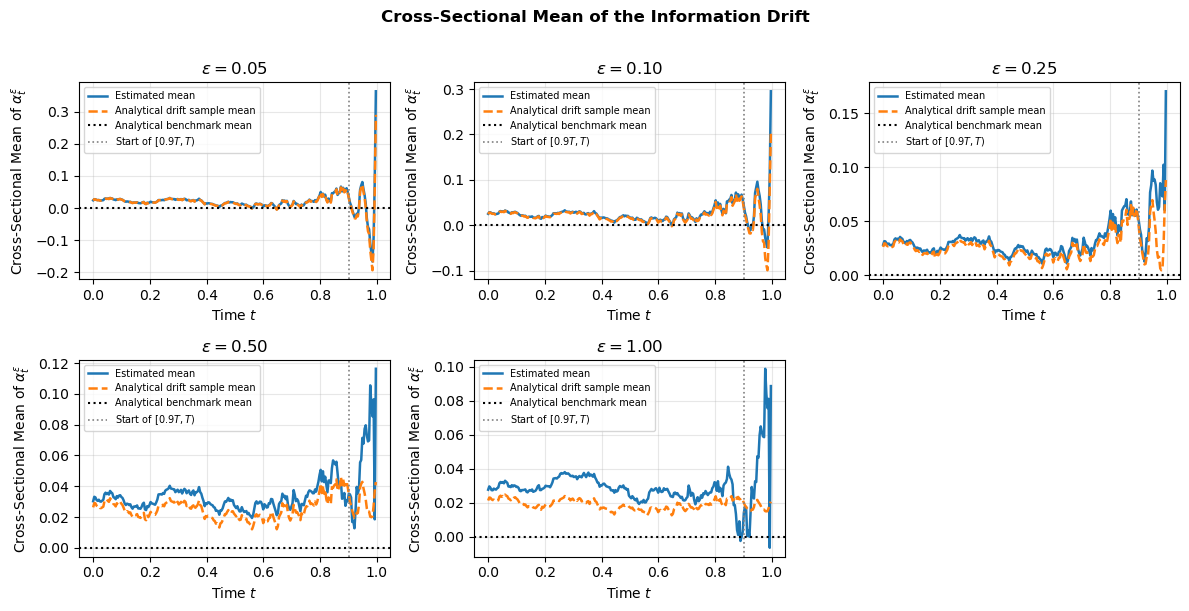


Information drift mean figure saved as information_drift_mean.png


In [18]:
# ==================================================
# Plot the cross-sectional mean
# of the information drift
# ==================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 6),
    sharex=False
)

# Convert the two-dimensional axes array
# into a one-dimensional array
axes = axes.flatten()


# ==================================================
# Create one subplot for each noise level
# ==================================================

for plot_index, epsilon in enumerate(
    noise_levels
):

    ax = axes[plot_index]

    # Select and sort the information drift results
    # for the current noise level
    epsilon_results = (
        information_drift_results_df[
            np.isclose(
                information_drift_results_df[
                    "Noise level"
                ],
                epsilon
            )
        ]
        .sort_values("Time")
    )

    # ----------------------------------------------
    # Mean of regression-based drift estimates
    # ----------------------------------------------

    ax.plot(
        epsilon_results["Time"],
        epsilon_results["Estimated mean"],
        color="tab:blue",
        linewidth=1.8,
        label="Estimated mean"
    )

    # ----------------------------------------------
    # Sample mean of the analytical drift
    # on the same testing paths
    # ----------------------------------------------

    ax.plot(
        epsilon_results["Time"],
        epsilon_results[
            "Analytical drift sample mean"
        ],
        color="tab:orange",
        linestyle="--",
        linewidth=1.8,
        label="Analytical drift sample mean"
    )

    # ----------------------------------------------
    # Analytical benchmark mean
    # ----------------------------------------------

    ax.axhline(
        y=0,
        color="black",
        linestyle=":",
        linewidth=1.5,
        label="Analytical benchmark mean"
    )

    # ----------------------------------------------
    # Start of the near-maturity region
    # ----------------------------------------------

    ax.axvline(
        x=near_maturity_start,
        color="grey",
        linestyle=":",
        linewidth=1.2,
        label=r"Start of $[0.9T,T)$"
    )

    # ----------------------------------------------
    # Subplot formatting
    # ----------------------------------------------

    ax.set_title(
        rf"$\varepsilon={epsilon:.2f}$",
        fontweight="bold"
    )

    ax.set_xlabel(
        r"Time $t$"
    )

    ax.set_ylabel(
        r"Cross-Sectional Mean of "
        r"$\alpha_t^\varepsilon$"
    )

    ax.grid(
        alpha=0.3
    )

    ax.legend(
        fontsize=7
    )


# ==================================================
# Remove the unused sixth subplot
# ==================================================

fig.delaxes(
    axes[-1]
)


# ==================================================
# Add the overall title
# ==================================================

fig.suptitle(
    "Cross-Sectional Mean of the Information Drift",
    fontweight="bold",
    y=1.01
)

fig.tight_layout()


# ==================================================
# Save and display the figure
# ==================================================

drift_mean_filename = (
    "information_drift_mean.png"
)

fig.savefig(
    drift_mean_filename,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\nInformation drift mean figure saved as "
    f"{drift_mean_filename}"
)

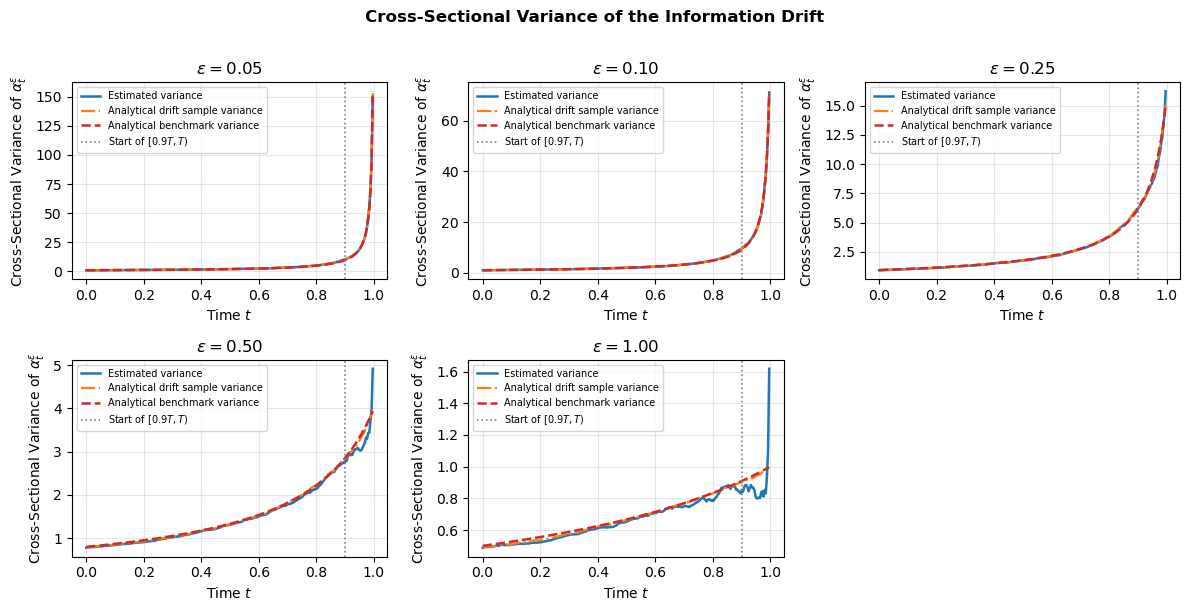


Information drift variance figure saved as information_drift_variance.png


In [23]:
# ==================================================
# Plot the cross-sectional variance of the information drift
# ==================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 6),
    sharex=False
)

# Convert the two-dimensional axes array
# into a one-dimensional array
axes = axes.flatten()


# ==================================================
# Create one subplot for each noise level
# ==================================================

for plot_index, epsilon in enumerate(
    noise_levels
):

    ax = axes[plot_index]

    # Select and sort the information drift results
    # for the current noise level
    epsilon_results = (
        information_drift_results_df[
            np.isclose(
                information_drift_results_df[
                    "Noise level"
                ],
                epsilon
            )
        ]
        .sort_values("Time")
    )

    # ----------------------------------------------
    # Variance of regression-based drift estimates
    # ----------------------------------------------

    ax.plot(
        epsilon_results["Time"],
        epsilon_results[
            "Estimated variance"
        ],
        color="tab:blue",
        linewidth=1.8,
        label="Estimated variance"
    )

    # ----------------------------------------------
    # Sample variance of the analytical drift on the same testing paths
    # ----------------------------------------------

    ax.plot(
        epsilon_results["Time"],
        epsilon_results[
            "Analytical drift sample variance"
        ],
        color="tab:orange",
        linestyle="-.",
        linewidth=1.6,
        label="Analytical drift sample variance"
    )

    # ----------------------------------------------
    # Analytical benchmark variance
    # ----------------------------------------------

    ax.plot(
        epsilon_results["Time"],
        epsilon_results[
            "Analytical benchmark variance"
        ],
        color="tab:red",
        linestyle="--",
        linewidth=1.8,
        label="Analytical benchmark variance"
    )

    # ----------------------------------------------
    # Start of the near-maturity region
    # ----------------------------------------------

    ax.axvline(
        x=near_maturity_start,
        color="grey",
        linestyle=":",
        linewidth=1.2,
        label=r"Start of $[0.9T,T)$"
    )

    # ----------------------------------------------
    # Subplot formatting
    # ----------------------------------------------

    ax.set_title(
        rf"$\varepsilon={epsilon:.2f}$",
        fontweight="bold"
    )

    ax.set_xlabel(
        r"Time $t$"
    )

    ax.set_ylabel(
        r"Cross-Sectional Variance of "
        r"$\alpha_t^\varepsilon$"
    )

    ax.grid(
        alpha=0.3
    )

    ax.legend(
        fontsize=7
    )


# ==================================================
# Remove the unused sixth subplot
# ==================================================

fig.delaxes(
    axes[-1]
)


# ==================================================
# Add the overall title
# ==================================================

fig.suptitle(
    "Cross-Sectional Variance of the Information Drift",
    fontweight="bold",
    y=1.01
)

fig.tight_layout()


# ==================================================
# Save and display the figure
# ==================================================

drift_variance_filename = (
    "information_drift_variance.png"
)

fig.savefig(
    drift_variance_filename,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\nInformation drift variance figure saved as "
    f"{drift_variance_filename}"
)

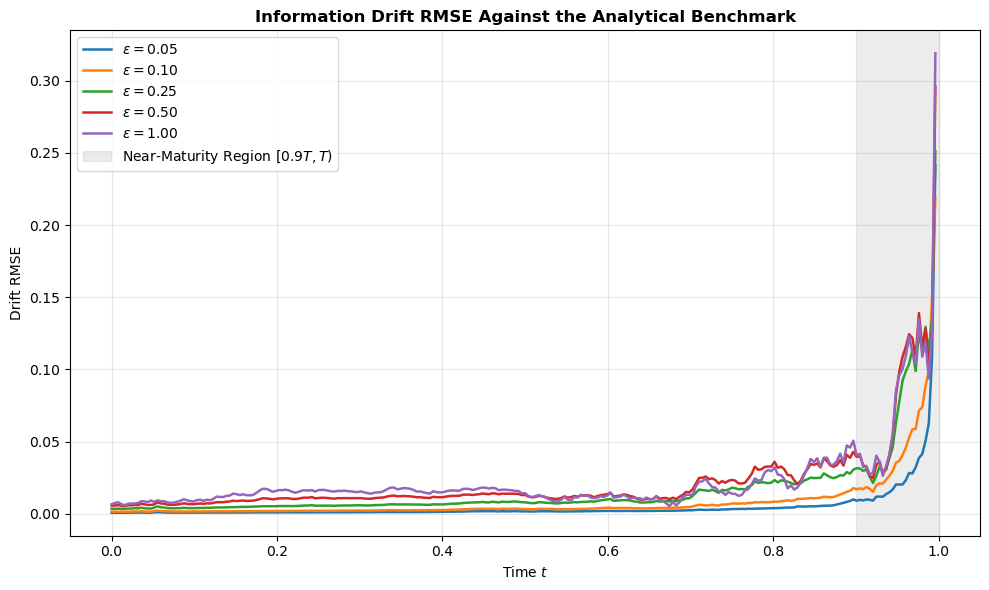


Information drift RMSE figure saved as information_drift_rmse.png


In [24]:
# ==================================================
# Plot the information drift RMSE over the full interval
# ==================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)


# ==================================================
# Plot the RMSE for each noise level
# ==================================================

for epsilon in noise_levels:

    # Select and sort the information drift results
    # for the current noise level
    epsilon_results = (
        information_drift_results_df[
            np.isclose(
                information_drift_results_df[
                    "Noise level"
                ],
                epsilon
            )
        ]
        .sort_values("Time")
    )

    # Plot the RMSE between the regression-based
    # drift estimate and the analytical drift
    # benchmark
    ax.plot(
        epsilon_results["Time"],
        epsilon_results[
            "Drift vs analytical benchmark RMSE"
        ],
        linewidth=1.8,
        label=rf"$\varepsilon={epsilon:.2f}$"
    )


# ==================================================
# Highlight the near-maturity region
# ==================================================

ax.axvspan(
    near_maturity_start,
    T,
    color="grey",
    alpha=0.15,
    label=r"Near-Maturity Region $[0.9T,T)$"
)


# ==================================================
# Figure formatting
# ==================================================

ax.set_title(
    "Information Drift RMSE Against "
    "the Analytical Benchmark",
    fontweight="bold"
)

ax.set_xlabel(
    r"Time $t$"
)

ax.set_ylabel(
    r"Drift RMSE"
)

ax.grid(
    alpha=0.3
)

ax.legend()

fig.tight_layout()


# ==================================================
# Save and display the figure
# ==================================================

drift_rmse_filename = (
    "information_drift_rmse.png"
)

fig.savefig(
    drift_rmse_filename,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\nInformation drift RMSE figure saved as "
    f"{drift_rmse_filename}"
)

In [22]:
# ==================================================
# Near-maturity analysis
# ==================================================

# Identify rows belonging to the near-maturity
# region [0.9T, T)
near_maturity_results_mask = (
    information_drift_results_df["Time"]
    >= near_maturity_start
)

# Extract all information drift results in the
# near-maturity region
near_maturity_results = (
    information_drift_results_df[
        near_maturity_results_mask
    ]
    .copy()
)



# Store the near-maturity summary statistics
near_maturity_summary = []


# ==================================================
# Calculate the summary for each noise level
# ==================================================

for epsilon in noise_levels:

    # Select and sort the near-maturity results
    # for the current noise level
    epsilon_near_results = (
        near_maturity_results[
            np.isclose(
                near_maturity_results[
                    "Noise level"
                ],
                epsilon
            )
        ]
        .sort_values("Time")
    )

    # Select the final observation before maturity:
    # t = (N - 1) / N
    final_result = (
        epsilon_near_results.iloc[-1]
    )

    # Store the near-maturity summary statistics
    maximum_rmse_row = epsilon_near_results.loc[
        epsilon_near_results[
            "Drift vs analytical benchmark RMSE"
        ].idxmax()
    ]


    near_maturity_summary.append({
        "Noise level":
            epsilon,

        # Average absolute value of the estimated
        # cross-sectional mean over [0.9T, T)
        "Mean absolute estimated drift mean":
            np.mean(
                np.abs(
                    epsilon_near_results[
                        "Estimated mean"
                    ]
                )
            ),

        # Estimated cross-sectional mean at the
        # final grid point before maturity
        "Estimated mean at final grid point":
            final_result[
                "Estimated mean"
            ],

        # Sample mean of the analytical drift at
        # the final grid point on testing paths
        "Analytical drift sample mean at final grid point":
            final_result[
                "Analytical drift sample mean"
            ],

        # Average drift RMSE over [0.9T, T)
        "Mean near-maturity RMSE":
            epsilon_near_results[
                "Drift vs analytical benchmark RMSE"
            ].mean(),

        # Maximum drift RMSE over [0.9T, T)
        "Maximum near-maturity RMSE":
            epsilon_near_results[
                "Drift vs analytical benchmark RMSE"
            ].max(),

        # Drift RMSE at the final grid point
        "RMSE at final grid point":
            final_result[
                "Drift vs analytical benchmark RMSE"
            ],

        "Time of maximum near-maturity RMSE":
            maximum_rmse_row["Time"],

        # Estimated cross-sectional variance at
        # the final grid point
        "Estimated variance at final grid point":
            final_result[
                "Estimated variance"
            ],

        # Sample variance of the analytical drift
        # on testing paths at the final grid point
        "Analytical drift sample variance at final grid point":
            final_result[
                "Analytical drift sample variance"
            ],

        # Analytical variance benchmark at the
        # final grid point
        "Analytical benchmark variance at final grid point":
            final_result[
                "Analytical benchmark variance"
            ]
    })


# ==================================================
# Convert the summary into a table
# ==================================================

near_maturity_summary_df = pd.DataFrame(
    near_maturity_summary
)


# ==================================================
# Display the near-maturity summary
# ==================================================

print("\nNEAR-MATURITY INFORMATION DRIFT SUMMARY")
print("---------------------------------------")

print(
    near_maturity_summary_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ==================================================
# Save the near-maturity summary
# ==================================================

near_maturity_summary_filename = (
    "near_maturity_information_drift_summary.csv"
)

near_maturity_summary_df.to_csv(
    near_maturity_summary_filename,
    index=False
)

print(
    f"\nNear-maturity summary saved as "
    f"{near_maturity_summary_filename}"
)


NEAR-MATURITY INFORMATION DRIFT SUMMARY
---------------------------------------
 Noise level  Mean absolute estimated drift mean  Estimated mean at final grid point  Analytical drift sample mean at final grid point  Mean near-maturity RMSE  Maximum near-maturity RMSE  RMSE at final grid point  Time of maximum near-maturity RMSE  Estimated variance at final grid point  Analytical drift sample variance at final grid point  Analytical benchmark variance at final grid point
      0.0500                              0.0645                              0.3636                                            0.2903                   0.0342                      0.2414                    0.2414                              0.9960                                148.6905                                              153.0962                                           154.6012
      0.1000                              0.0463                              0.2951                                            0

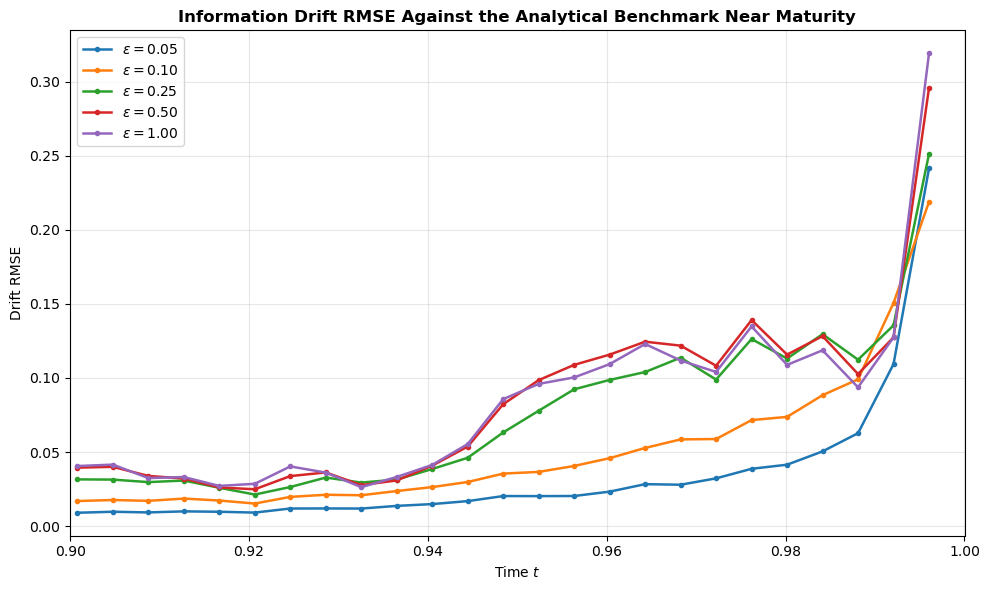


Near-maturity RMSE figure saved as information_drift_near_maturity_rmse.png


In [26]:
# ==================================================
# Plot the information drift RMSE in the near-maturity region
# ==================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)


# ==================================================
# Plot the RMSE for each noise level
# ==================================================

for epsilon in noise_levels:

    # Select and sort the near-maturity results
    # for the current noise level
    epsilon_near_results = (
        near_maturity_results[
            np.isclose(
                near_maturity_results[
                    "Noise level"
                ],
                epsilon
            )
        ]
        .sort_values("Time")
    )

    # Plot the RMSE between the regression-based
    # information drift estimate and the
    # analytical drift benchmark
    ax.plot(
        epsilon_near_results["Time"],
        epsilon_near_results[
            "Drift vs analytical benchmark RMSE"
        ],
        linewidth=1.8,
        marker="o",
        markersize=3,
        label=rf"$\varepsilon={epsilon:.2f}$"
    )


# ==================================================
# Figure formatting
# ==================================================

ax.set_title(
    "Information Drift RMSE Against the Analytical "
    "Benchmark Near Maturity",
    fontweight="bold"
)

ax.set_xlabel(
    r"Time $t$"
)

ax.set_ylabel(
    r"Drift RMSE"
)

ax.set_xlim(
    near_maturity_start,
    T
)

ax.grid(
    alpha=0.3
)

ax.legend()

fig.tight_layout()


# ==================================================
# Save and display the figure
# ==================================================

near_maturity_rmse_filename = (
    "information_drift_near_maturity_rmse.png"
)

fig.savefig(
    near_maturity_rmse_filename,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\nNear-maturity RMSE figure saved as "
    f"{near_maturity_rmse_filename}"
)

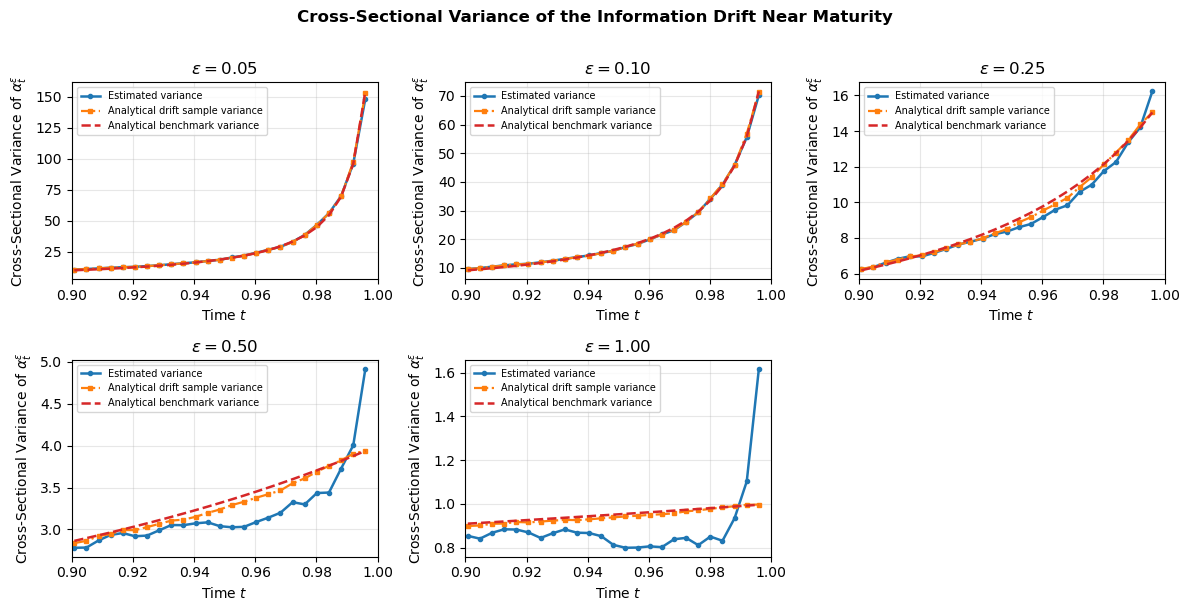


Near-maturity variance figure saved as information_drift_near_maturity_variance.png


In [27]:
# ==================================================
# Plot the cross-sectional variance
# in the near-maturity region
# ==================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 6),
    sharex=False
)

# Convert the two-dimensional axes array
# into a one-dimensional array
axes = axes.flatten()


# ==================================================
# Create one subplot for each noise level
# ==================================================

for plot_index, epsilon in enumerate(
    noise_levels
):

    ax = axes[plot_index]

    # Select and sort the near-maturity results
    # for the current noise level
    epsilon_near_results = (
        near_maturity_results[
            np.isclose(
                near_maturity_results[
                    "Noise level"
                ],
                epsilon
            )
        ]
        .sort_values("Time")
    )

    # ----------------------------------------------
    # Variance of regression-based drift estimates
    # ----------------------------------------------

    ax.plot(
        epsilon_near_results["Time"],
        epsilon_near_results[
            "Estimated variance"
        ],
        color="tab:blue",
        linewidth=1.8,
        marker="o",
        markersize=3,
        label="Estimated variance"
    )

    # ----------------------------------------------
    # Sample variance of the analytical drift
    # on the same testing paths
    # ----------------------------------------------

    ax.plot(
        epsilon_near_results["Time"],
        epsilon_near_results[
            "Analytical drift sample variance"
        ],
        color="tab:orange",
        linestyle="-.",
        linewidth=1.6,
        marker="s",
        markersize=3,
        label="Analytical drift sample variance"
    )

    # ----------------------------------------------
    # Analytical benchmark variance
    # ----------------------------------------------

    ax.plot(
        epsilon_near_results["Time"],
        epsilon_near_results[
            "Analytical benchmark variance"
        ],
        color="tab:red",
        linestyle="--",
        linewidth=1.8,
        label="Analytical benchmark variance"
    )

    # ----------------------------------------------
    # Subplot formatting
    # ----------------------------------------------

    ax.set_title(
        rf"$\varepsilon={epsilon:.2f}$",
        fontweight="bold"
    )

    ax.set_xlabel(
        r"Time $t$"
    )

    ax.set_ylabel(
        r"Cross-Sectional Variance of "
        r"$\alpha_t^\varepsilon$"
    )

    ax.set_xlim(
        near_maturity_start,
        T
    )

    ax.grid(
        alpha=0.3
    )

    ax.legend(
        fontsize=7
    )


# ==================================================
# Remove the unused sixth subplot
# ==================================================

fig.delaxes(
    axes[-1]
)


# ==================================================
# Add the overall title
# ==================================================

fig.suptitle(
    "Cross-Sectional Variance of the Information "
    "Drift Near Maturity",
    fontweight="bold",
    y=1.01
)

fig.tight_layout()


# ==================================================
# Save and display the figure
# ==================================================

near_maturity_variance_filename = (
    "information_drift_near_maturity_variance.png"
)

fig.savefig(
    near_maturity_variance_filename,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\nNear-maturity variance figure saved as "
    f"{near_maturity_variance_filename}"
)

# Step 6: Measuring the Strength of the Enlargement

In [28]:
# ============================================================
# Strength of the filtration enlargement
# ============================================================

# Time-step size:
# Delta t = T / N
dt = T / N

# Information drift observation times:
# 0, 1/252, ..., 251/252
#
# The maturity time T is excluded.
time_drift = drift_time_grid

# Store the pathwise integrated squared
# information drift for each noise level
pathwise_enlargement_strength = {}

# Store summary results for each noise level
enlargement_strength_results = []


# ============================================================
# Calculate the enlargement strength
# ============================================================

for epsilon in noise_levels:

    # Regression-based information drift estimates
    # on all testing paths
    #
    # Shape:
    # (number of drift observation times,
    #  number of testing paths)
    estimated_alpha = np.asarray(
        estimated_information_drifts[
            epsilon
        ]
    )

    # Expected array shape
    expected_shape = (
        len(time_drift),
        len(testing_indices)
    )

    # ----------------------------------------------
    # Validate the information drift array
    # ----------------------------------------------

    if estimated_alpha.shape != expected_shape:
        raise ValueError(
            f"For epsilon={epsilon:.2f}, expected shape "
            f"{expected_shape}, but obtained "
            f"{estimated_alpha.shape}."
        )

    if not np.all(
        np.isfinite(estimated_alpha)
    ):
        raise ValueError(
            f"Non-finite drift values were found "
            f"for epsilon={epsilon:.2f}."
        )

    # ----------------------------------------------
    # 1. Pathwise integrated squared drift
    # ----------------------------------------------

    # For each testing path m:
    #
    # I_hat_m(epsilon)
    # = sum from i=0 to N-1 of
    #   alpha_hat_(t_i,m)^2 * Delta t
    #
    # axis=0 means that the sum is taken over
    # observation times separately for each path.
    estimated_pathwise_strength = np.sum(
        estimated_alpha**2,
        axis=0
    ) * dt

    # Store the complete pathwise results
    pathwise_enlargement_strength[
        epsilon
    ] = estimated_pathwise_strength

    # ----------------------------------------------
    # 2. Estimated enlargement strength
    # ----------------------------------------------

    # Average the pathwise integrated squared
    # drifts over all testing paths
    estimated_strength = np.mean(
        estimated_pathwise_strength
    )

    # Sample standard deviation of the pathwise
    # integrated squared drift
    pathwise_standard_deviation = np.std(
        estimated_pathwise_strength,
        ddof=1
    )

    # Monte Carlo standard error of the estimated
    # enlargement strength
    monte_carlo_standard_error = (
        pathwise_standard_deviation
        / np.sqrt(
            len(testing_indices)
        )
    )

    # Approximate 95% confidence interval
    confidence_interval_lower = (
        estimated_strength
        - 1.96 * monte_carlo_standard_error
    )

    confidence_interval_upper = (
        estimated_strength
        + 1.96 * monte_carlo_standard_error
    )

    # ----------------------------------------------
    # 3. Continuous analytical benchmark
    # ----------------------------------------------

    # Continuous-time analytical benchmark:
    #
    # integral from 0 to T of
    # 1 / (T - t + epsilon^2) dt
    #
    # = log((T + epsilon^2) / epsilon^2)
    continuous_analytical_benchmark = np.log(
        (T + epsilon**2)
        / epsilon**2
    )

    # ----------------------------------------------
    # 4. Discrete analytical benchmark
    # ----------------------------------------------

    # Analytical variance benchmark of the
    # information drift at each grid point:
    #
    # Var(alpha_t)
    # = 1 / (T - t + epsilon^2)
    analytical_variance_benchmark = (
        1
        / (
            T
            - time_drift
            + epsilon**2
        )
    )

    # Grid-matched analytical benchmark using
    # the same left Riemann sum as the numerical
    # enlargement-strength estimate
    discrete_analytical_benchmark = np.sum(
        analytical_variance_benchmark
    ) * dt

    # ----------------------------------------------
    # 5. Differences from the analytical benchmarks
    # ----------------------------------------------

    # Difference from the grid-matched
    # analytical benchmark
    difference_from_discrete_benchmark = (
        estimated_strength
        - discrete_analytical_benchmark
    )

    relative_error_from_discrete_benchmark = (
        difference_from_discrete_benchmark
        / discrete_analytical_benchmark
        * 100
    )

    # Difference from the continuous-time
    # analytical benchmark
    difference_from_continuous_benchmark = (
        estimated_strength
        - continuous_analytical_benchmark
    )

    relative_error_from_continuous_benchmark = (
        difference_from_continuous_benchmark
        / continuous_analytical_benchmark
        * 100
    )

    # ----------------------------------------------
    # Store the summary results
    # ----------------------------------------------

    enlargement_strength_results.append({
        "Noise level":
            epsilon,
        "Number of testing paths":
            len(testing_indices),
        "Estimated strength":
            estimated_strength,
        "Pathwise standard deviation":
            pathwise_standard_deviation,
        "Monte Carlo standard error":
            monte_carlo_standard_error,
        "95% CI lower":
            confidence_interval_lower,
        "95% CI upper":
            confidence_interval_upper,
        "Discrete analytical benchmark":
            discrete_analytical_benchmark,
        "Continuous analytical benchmark":
            continuous_analytical_benchmark,
        "Difference from discrete benchmark":
            difference_from_discrete_benchmark,
        "Relative error from discrete benchmark (%)":
            relative_error_from_discrete_benchmark,
        "Difference from continuous benchmark":
            difference_from_continuous_benchmark,
        "Relative error from continuous benchmark (%)":
            relative_error_from_continuous_benchmark
    })


# ============================================================
# Convert the results into a table
# ============================================================

enlargement_strength_results_df = pd.DataFrame(
    enlargement_strength_results
)


# ============================================================
# Display the results
# ============================================================

print(
    "\nSTRENGTH OF THE FILTRATION ENLARGEMENT"
)

print(
    "---------------------------------------"
)

print(
    enlargement_strength_results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


STRENGTH OF THE FILTRATION ENLARGEMENT
---------------------------------------
 Noise level  Number of testing paths  Estimated strength  Pathwise standard deviation  Monte Carlo standard error  95% CI lower  95% CI upper  Discrete analytical benchmark  Continuous analytical benchmark  Difference from discrete benchmark  Relative error from discrete benchmark (%)  Difference from continuous benchmark  Relative error from continuous benchmark (%)
    0.050000                     2000            5.438610                     4.310086                    0.096376      5.249712      5.627508                       5.382415                         5.993961                            0.056195                                    1.044041                             -0.555352                                     -9.265186
    0.100000                     2000            4.460007                     3.782039                    0.084569      4.294252      4.625763                       4.431600     

In [29]:
# ============================================================
# Create the main enlargement-strength summary
# ============================================================

enlargement_strength_summary_df = (
    enlargement_strength_results_df[[
        "Noise level",
        "Estimated strength",
        "Discrete analytical benchmark",
        "Relative error from discrete benchmark (%)"
    ]]
    .copy()
)


# ============================================================
# Display the summary
# ============================================================

print(
    "\nENLARGEMENT-STRENGTH SUMMARY"
)

print(
    "----------------------------"
)

print(
    enlargement_strength_summary_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


ENLARGEMENT-STRENGTH SUMMARY
----------------------------
 Noise level  Estimated strength  Discrete analytical benchmark  Relative error from discrete benchmark (%)
      0.0500              5.4386                         5.3824                                      1.0440
      0.1000              4.4600                         4.4316                                      0.6410
      0.2500              2.7763                         2.8037                                     -0.9778
      0.5000              1.5626                         1.6031                                     -2.5270
      1.0000              0.6705                         0.6922                                     -3.1281


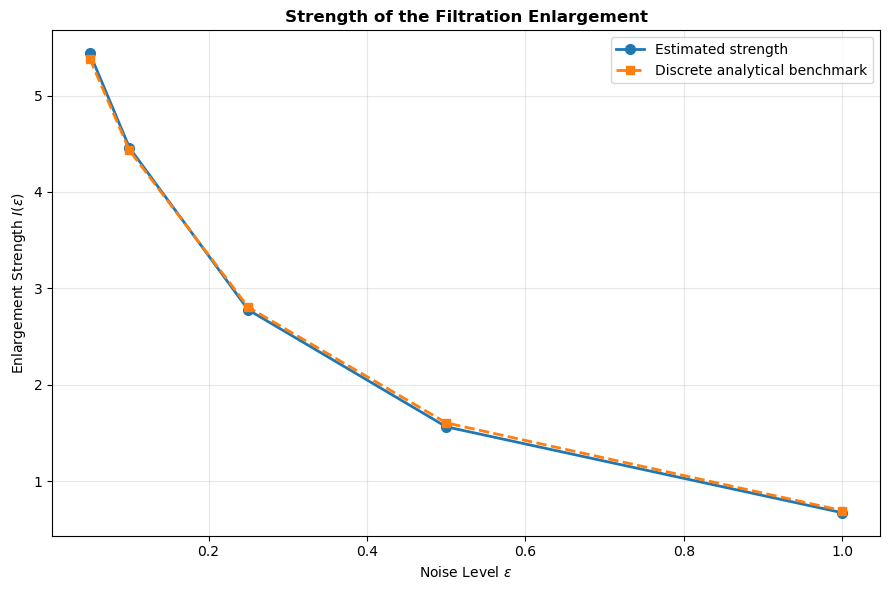


Enlargement-strength figure saved as filtration_enlargement_strength.png


In [30]:
# ============================================================
# Prepare data for the enlargement-strength figure
# ============================================================

epsilon_plot = (
    enlargement_strength_results_df[
        "Noise level"
    ].to_numpy()
)

estimated_strength_plot = (
    enlargement_strength_results_df[
        "Estimated strength"
    ].to_numpy()
)

discrete_benchmark_plot = (
    enlargement_strength_results_df[
        "Discrete analytical benchmark"
    ].to_numpy()
)


# ============================================================
# Plot the strength of the filtration enlargement
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 6)
)

# Estimated enlargement strength
ax.plot(
    epsilon_plot,
    estimated_strength_plot,
    color="tab:blue",
    marker="o",
    linewidth=2,
    markersize=7,
    label="Estimated strength"
)

# Grid-matched analytical benchmark
ax.plot(
    epsilon_plot,
    discrete_benchmark_plot,
    color="tab:orange",
    marker="s",
    linestyle="--",
    linewidth=2,
    markersize=6,
    label="Discrete analytical benchmark"
)


# ============================================================
# Figure formatting
# ============================================================

ax.set_xlabel(
    r"Noise Level $\varepsilon$"
)

ax.set_ylabel(
    r"Enlargement Strength $I(\varepsilon)$"
)

ax.set_title(
    "Strength of the Filtration Enlargement",
    fontweight="bold"
)

ax.grid(
    alpha=0.3
)

ax.legend()

fig.tight_layout()


# ============================================================
# Save and display the figure
# ============================================================

enlargement_strength_figure_filename = (
    "filtration_enlargement_strength.png"
)

fig.savefig(
    enlargement_strength_figure_filename,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\nEnlargement-strength figure saved as "
    f"{enlargement_strength_figure_filename}"
)

In [31]:
# ============================================================
# Numerical checks
# ============================================================

# Sort the results by noise level before checking
# whether the strengths decrease
ordered_strength_results = (
    enlargement_strength_results_df
    .sort_values("Noise level")
)

estimated_strength_check = (
    ordered_strength_results[
        "Estimated strength"
    ].to_numpy()
)

discrete_benchmark_check = (
    ordered_strength_results[
        "Discrete analytical benchmark"
    ].to_numpy()
)

# Check whether the estimated strength strictly
# decreases across the tested noise levels
estimated_strength_decreasing = np.all(
    np.diff(
        estimated_strength_check
    ) < 0
)

# Check whether the discrete analytical benchmark
# strictly decreases across the tested noise levels
discrete_benchmark_decreasing = np.all(
    np.diff(
        discrete_benchmark_check
    ) < 0
)

# Find the largest absolute relative error from
# the discrete analytical benchmark
maximum_absolute_relative_error = np.max(
    np.abs(
        ordered_strength_results[
            "Relative error from discrete benchmark (%)"
        ].to_numpy()
    )
)

print("\nNUMERICAL CHECKS")
print("----------------")

print(
    "Estimated strength strictly decreases "
    "across the tested noise levels:",
    estimated_strength_decreasing
)

print(
    "Discrete analytical benchmark strictly "
    "decreases across the tested noise levels:",
    discrete_benchmark_decreasing
)

print(
    "Maximum absolute relative error from the "
    "discrete analytical benchmark:"
)

print(
    f"{maximum_absolute_relative_error:.4f}%"
)


NUMERICAL CHECKS
----------------
Estimated strength strictly decreases across the tested noise levels: True
Discrete analytical benchmark strictly decreases across the tested noise levels: True
Maximum absolute relative error from the discrete analytical benchmark:
3.1281%


# Step 7: Verification of the Semimartingale Decomposition

In [32]:
# ============================================================
# Verification of the semimartingale decomposition
# ============================================================

from scipy.stats import skew, kurtosis


# Store the adjusted Brownian processes
adjusted_brownian_paths = {}

# Store the mean and variance at each time
semimartingale_results = []

# Store the increment distribution statistics
increment_results = []


for epsilon in noise_levels:

    # Estimated information drift on testing paths
    #
    # Shape:
    # (252 observation times, 2000 testing paths)
    estimated_alpha = (
        estimated_information_drifts[
            epsilon
        ]
    )

    # Brownian paths in the testing sample
    #
    # Shape:
    # (253 observation times, 2000 testing paths)
    brownian_test = brownian_paths[
        :,
        testing_indices
    ]

    # --------------------------------------------------------
    # Approximate the integrated information drift
    # --------------------------------------------------------

    # At t = 0, the integral is zero.
    #
    # At each later time:
    # integral alpha_s ds
    # approximately equals the cumulative left Riemann sum.

    integrated_alpha = np.vstack(
        (
            np.zeros(
                (
                    1,
                    len(testing_indices)
                )
            ),
            np.cumsum(
                estimated_alpha * delta_t_sim,
                axis=0
            )
        )
    )

    # --------------------------------------------------------
    # Construct the adjusted Brownian process
    #
    # W_tilde_t
    # = W_t - integral from 0 to t of alpha_s ds
    # --------------------------------------------------------

    adjusted_brownian = (
        brownian_test
        - integrated_alpha
    )

    adjusted_brownian_paths[
        epsilon
    ] = adjusted_brownian

    # --------------------------------------------------------
    # 1. Mean and variance at each observation time
    # --------------------------------------------------------

    for time_index, t in enumerate(
        time_grid
    ):

        adjusted_values = adjusted_brownian[
            time_index,
            :
        ]

        semimartingale_results.append({
            "Time":
                t,
            "Noise level":
                epsilon,
            "Adjusted mean":
                np.mean(
                    adjusted_values
                ),
            "Adjusted variance":
                np.var(
                    adjusted_values,
                    ddof=1
                ),
            "Brownian variance benchmark":
                t
        })

    # --------------------------------------------------------
    # 2. Distribution of the increments
    # --------------------------------------------------------

    adjusted_increments = np.diff(
        adjusted_brownian,
        axis=0
    )

    # If the adjusted process is Brownian,
    #
    # Delta W_tilde / sqrt(Delta t)
    #
    # should be approximately N(0, 1).

    standardised_increments = (
        adjusted_increments
        / np.sqrt(delta_t_sim)
    )

    pooled_standardised_increments = (
        standardised_increments.ravel()
    )

    increment_results.append({
        "Noise level":
            epsilon,
        "Standardised increment mean":
            np.mean(
                pooled_standardised_increments
            ),
        "Standardised increment standard deviation":
            np.std(
                pooled_standardised_increments,
                ddof=1
            ),
        "Standardised increment skewness":
            skew(
                pooled_standardised_increments,
                bias=False
            ),
        "Standardised increment excess kurtosis":
            kurtosis(
                pooled_standardised_increments,
                fisher=True,
                bias=False
            )
    })


# Convert the results into DataFrames
semimartingale_results_df = pd.DataFrame(
    semimartingale_results
)

increment_results_df = pd.DataFrame(
    increment_results
)


print(
    "\nSTANDARDISED INCREMENT RESULTS"
)

print(
    "------------------------------"
)

print(
    increment_results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


STANDARDISED INCREMENT RESULTS
------------------------------
 Noise level  Standardised increment mean  Standardised increment standard deviation  Standardised increment skewness  Standardised increment excess kurtosis
    0.050000                     0.000228                                   0.989920                        -0.003350                                0.016785
    0.100000                    -0.000134                                   0.991807                        -0.003445                                0.010420
    0.250000                    -0.000649                                   0.995055                        -0.003685                                0.007805
    0.500000                    -0.000736                                   0.997457                        -0.003917                                0.007979
    1.000000                    -0.000410                                   0.999273                        -0.004098                              

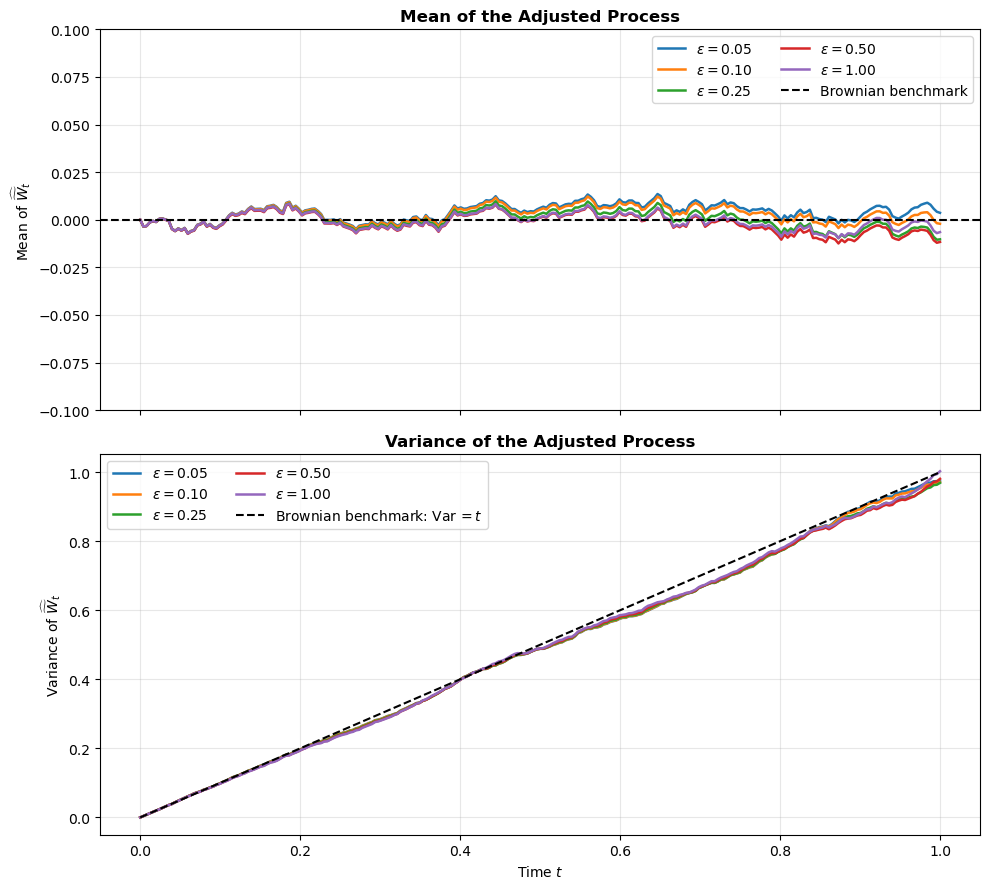


Semimartingale mean-variance figure saved as semimartingale_mean_variance.png


In [33]:
# ============================================================
# Plot the mean and variance of the adjusted process
# ============================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 9),
    sharex=True
)


# ------------------------------------------------------------
# Panel 1: Mean of the adjusted process
# ------------------------------------------------------------

for epsilon in noise_levels:

    epsilon_results = (
        semimartingale_results_df[
            semimartingale_results_df[
                "Noise level"
            ] == epsilon
        ]
        .sort_values("Time")
    )

    axes[0].plot(
        epsilon_results["Time"],
        epsilon_results["Adjusted mean"],
        linewidth=1.8,
        label=(
            rf"$\varepsilon={epsilon:.2f}$"
        )
    )

# Brownian benchmark:
# E[W_tilde_t] = 0
axes[0].axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Brownian benchmark"
)

# Fix the vertical range so that the small
# deviations around zero are shown in context.
axes[0].set_ylim(
    -0.1,
    0.1
)

axes[0].set_ylabel(
    r"Mean of $\widehat{\widetilde{W}}_t$"
)

axes[0].set_title(
    "Mean of the Adjusted Process",
    fontweight="bold"
)

axes[0].grid(
    alpha=0.3
)

axes[0].legend(
    ncol=2
)


# ------------------------------------------------------------
# Panel 2: Variance of the adjusted process
# ------------------------------------------------------------

for epsilon in noise_levels:

    epsilon_results = (
        semimartingale_results_df[
            semimartingale_results_df[
                "Noise level"
            ] == epsilon
        ]
        .sort_values("Time")
    )

    axes[1].plot(
        epsilon_results["Time"],
        epsilon_results["Adjusted variance"],
        linewidth=1.8,
        label=(
            rf"$\varepsilon={epsilon:.2f}$"
        )
    )

# Brownian benchmark:
# Var(W_tilde_t) = t
axes[1].plot(
    time_grid,
    time_grid,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=r"Brownian benchmark: $\operatorname{Var}=t$"
)

axes[1].set_xlabel(
    r"Time $t$"
)

axes[1].set_ylabel(
    r"Variance of $\widehat{\widetilde{W}}_t$"
)

axes[1].set_title(
    "Variance of the Adjusted Process",
    fontweight="bold"
)

axes[1].grid(
    alpha=0.3
)

axes[1].legend(
    ncol=2
)


# ------------------------------------------------------------
# Save and display the figure
# ------------------------------------------------------------

fig.tight_layout()

semimartingale_figure_filename = (
    "semimartingale_mean_variance.png"
)

fig.savefig(
    semimartingale_figure_filename,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\nSemimartingale mean-variance figure saved as "
    f"{semimartingale_figure_filename}"
)

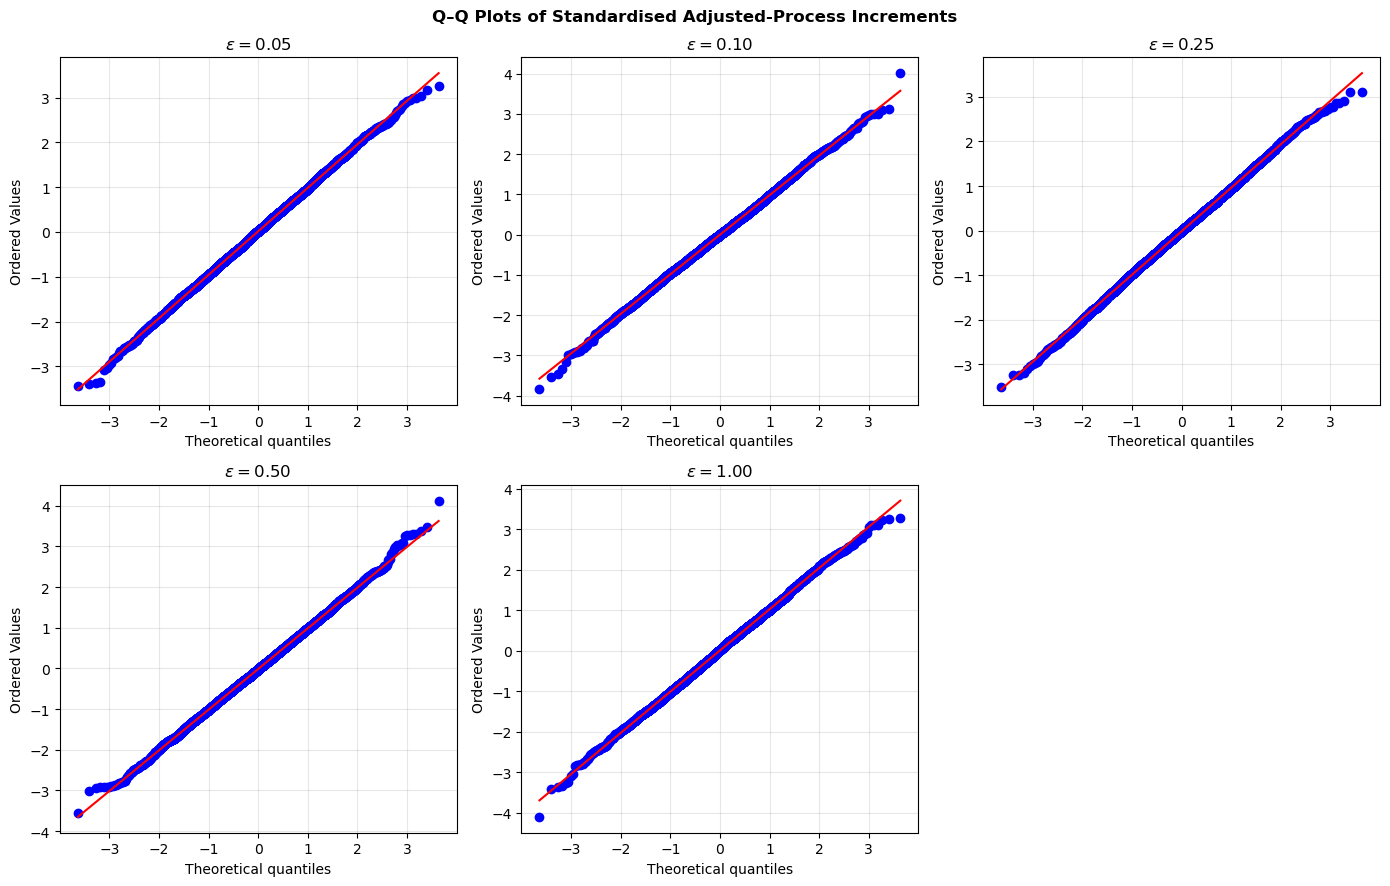

In [34]:
# ============================================================
# Q-Q plots of the standardised increments
# ============================================================

from scipy.stats import probplot


qq_rng = np.random.default_rng(42)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 9)
)

axes = axes.ravel()


for plot_index, epsilon in enumerate(
    noise_levels
):

    adjusted_brownian = (
        adjusted_brownian_paths[
            epsilon
        ]
    )

    standardised_increments = (
        np.diff(
            adjusted_brownian,
            axis=0
        )
        / np.sqrt(delta_t_sim)
    ).ravel()

    # Use a reproducible sample to keep
    # the Q-Q plot clear.
    sample_size = min(
        5000,
        len(standardised_increments)
    )

    sample_indices = qq_rng.choice(
        len(standardised_increments),
        size=sample_size,
        replace=False
    )

    qq_sample = standardised_increments[
        sample_indices
    ]

    probplot(
        qq_sample,
        dist="norm",
        plot=axes[plot_index]
    )

    axes[plot_index].set_title(
        rf"$\varepsilon={epsilon:.2f}$",
        fontweight="bold"
    )

    axes[plot_index].grid(
        alpha=0.3
    )


# Delete the unused sixth panel
fig.delaxes(
    axes[-1]
)

fig.suptitle(
    "Q–Q Plots of Standardised Adjusted-Process Increments",
    fontweight="bold"
)

fig.tight_layout()

fig.savefig(
    "semimartingale_increment_qq_plots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Step 9: Robustness and Sensitivity Analysis

In [40]:
# ============================================================
# Sensitivity to the number of Monte Carlo paths
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


# Monte Carlo sample sizes considered
sensitivity_path_numbers = [
    5000,
    10000,
    15000,
    20000
]

maximum_sensitivity_paths = max(
    sensitivity_path_numbers
)

# Number of additional paths required beyond
# the 10,000 paths used in the main experiment
number_of_additional_paths = (
    maximum_sensitivity_paths
    - number_of_paths
)


# ============================================================
# Extend the existing Monte Carlo sample
# ============================================================

# A separate seed is used only to generate the
# additional paths required by the sensitivity analysis.
sensitivity_extension_seed = 4242

sensitivity_extension_rng = np.random.default_rng(
    sensitivity_extension_seed
)

# Additional standard normal increments
additional_Z = sensitivity_extension_rng.standard_normal(
    size=(
        N,
        number_of_additional_paths
    )
)

# Combine the original paths with the additional paths.
#
# The first 10,000 columns are exactly the paths used
# in the main experiment.
sensitivity_Z = np.concatenate(
    (
        Z,
        additional_Z
    ),
    axis=1
)


# Generate additional independent signal noise
additional_noise_seed = 2027

additional_noise_rng = np.random.default_rng(
    additional_noise_seed
)

additional_xi = additional_noise_rng.standard_normal(
    number_of_additional_paths
)

# The first 10,000 values are exactly the signal-noise
# values used in the main experiment.
sensitivity_xi = np.concatenate(
    (
        xi,
        additional_xi
    )
)


# ============================================================
# Construct the maximum Brownian sample
# ============================================================

sensitivity_brownian_paths = np.zeros(
    (
        N + 1,
        maximum_sensitivity_paths
    )
)

sensitivity_brownian_paths[1:, :] = np.cumsum(
    np.sqrt(delta_t_sim)
    * sensitivity_Z,
    axis=0
)

sensitivity_terminal_values = (
    sensitivity_brownian_paths[
        -1,
        :
    ]
)


# ============================================================
# Observation times used for conditional prediction
# ============================================================

# These are the same representative times used
# in the main conditional-expectation validation.
sensitivity_prediction_indices = [
    0,
    int(0.25 * N),
    int(0.50 * N),
    int(0.75 * N)
]

# Information-drift robustness is assessed over
# t <= 0.90 to prevent the final maturity points
# from dominating the average RMSE.
sensitivity_drift_mask = (
    drift_time_grid <= 0.90 * T
)


# ============================================================
# Store sensitivity results
# ============================================================

sample_size_sensitivity_results = []


# ============================================================
# Repeat the experiment for each sample size
# ============================================================

for current_number_of_paths in sensitivity_path_numbers:

    print(
        f"\nRunning sample-size sensitivity for "
        f"M={current_number_of_paths:,}"
    )

    # Select the first M paths from the nested sample
    current_brownian_paths = (
        sensitivity_brownian_paths[
            :,
            :current_number_of_paths
        ]
    )

    current_terminal_values = (
        sensitivity_terminal_values[
            :current_number_of_paths
        ]
    )

    current_xi = sensitivity_xi[
        :current_number_of_paths
    ]

    # --------------------------------------------------------
    # Training-testing split
    # --------------------------------------------------------

    current_path_indices = np.arange(
        current_number_of_paths
    )

    (
        current_training_indices,
        current_testing_indices
    ) = train_test_split(
        current_path_indices,
        test_size=0.20,
        random_state=42,
        shuffle=True
    )

    current_number_of_testing_paths = len(
        current_testing_indices
    )

    # --------------------------------------------------------
    # Repeat the calculation for every noise level
    # --------------------------------------------------------

    for epsilon in noise_levels:

        # Noisy insider signal
        current_signal = (
            current_terminal_values
            + epsilon * current_xi
        )

        # Store the estimated and analytical information
        # drifts on the testing paths.
        #
        # Shape:
        # (N observation times, number of testing paths)
        current_estimated_alpha = np.empty(
            (
                N,
                current_number_of_testing_paths
            )
        )

        current_analytical_alpha = np.empty(
            (
                N,
                current_number_of_testing_paths
            )
        )

        # Store prediction RMSE at the selected times
        current_prediction_rmse_values = []

        # ----------------------------------------------------
        # Monte Carlo regression at each observation time
        # ----------------------------------------------------

        for time_index, t in enumerate(
            drift_time_grid
        ):

            current_brownian_values = (
                current_brownian_paths[
                    time_index,
                    :
                ]
            )

            # ----------------------------------------------
            # Regression inputs
            # ----------------------------------------------

            if time_index == 0:

                current_regression_inputs = (
                    current_signal.reshape(
                        -1,
                        1
                    )
                )

            else:

                current_regression_inputs = (
                    np.column_stack(
                        (
                            current_brownian_values,
                            current_signal
                        )
                    )
                )

            # ----------------------------------------------
            # Fit the regression
            # ----------------------------------------------

            current_model = LinearRegression()

            current_model.fit(
                current_regression_inputs[
                    current_training_indices
                ],
                current_terminal_values[
                    current_training_indices
                ]
            )

            # Predictions are required only on
            # the held-out testing paths.
            current_estimated_m_test = (
                current_model.predict(
                    current_regression_inputs[
                        current_testing_indices
                    ]
                )
            )

            # Brownian values on testing paths
            current_brownian_test = (
                current_brownian_values[
                    current_testing_indices
                ]
            )

            # Noisy signals on testing paths
            current_signal_test = (
                current_signal[
                    current_testing_indices
                ]
            )

            # ----------------------------------------------
            # Analytical conditional expectation
            # ----------------------------------------------

            current_signal_weight = (
                (T - t)
                / (
                    T
                    - t
                    + epsilon**2
                )
            )

            current_analytical_m_test = (
                current_brownian_test
                + current_signal_weight
                * (
                    current_signal_test
                    - current_brownian_test
                )
            )

            # ----------------------------------------------
            # Conditional-prediction RMSE
            # ----------------------------------------------

            if (
                time_index
                in sensitivity_prediction_indices
            ):

                current_prediction_rmse = np.sqrt(
                    np.mean(
                        (
                            current_estimated_m_test
                            - current_analytical_m_test
                        ) ** 2
                    )
                )

                current_prediction_rmse_values.append(
                    current_prediction_rmse
                )

            # ----------------------------------------------
            # Estimated information drift
            # ----------------------------------------------

            current_estimated_alpha[
                time_index,
                :
            ] = (
                current_estimated_m_test
                - current_brownian_test
            ) / (
                T - t
            )

            # ----------------------------------------------
            # Analytical information drift
            # ----------------------------------------------

            current_analytical_alpha[
                time_index,
                :
            ] = (
                current_signal_test
                - current_brownian_test
            ) / (
                T
                - t
                + epsilon**2
            )

        # ----------------------------------------------------
        # 1. Conditional-prediction sensitivity
        # ----------------------------------------------------

        mean_prediction_rmse = np.mean(
            current_prediction_rmse_values
        )

        # ----------------------------------------------------
        # 2. Information-drift sensitivity
        # ----------------------------------------------------

        # RMSE is first calculated separately
        # at each time point.
        current_drift_rmse_by_time = np.sqrt(
            np.mean(
                (
                    current_estimated_alpha
                    - current_analytical_alpha
                ) ** 2,
                axis=1
            )
        )

        # Average only over t <= 0.90.
        mean_drift_rmse_to_090 = np.mean(
            current_drift_rmse_by_time[
                sensitivity_drift_mask
            ]
        )

        # ----------------------------------------------------
        # 3. Enlargement-strength sensitivity
        # ----------------------------------------------------

        current_pathwise_strength = np.sum(
            current_estimated_alpha**2,
            axis=0
        ) * delta_t_sim

        current_estimated_strength = np.mean(
            current_pathwise_strength
        )

        # Grid-matched analytical benchmark
        current_discrete_benchmark = np.sum(
            1
            / (
                T
                - drift_time_grid
                + epsilon**2
            )
        ) * delta_t_sim

        current_strength_difference = (
            current_estimated_strength
            - current_discrete_benchmark
        )

        current_strength_relative_error = (
            current_strength_difference
            / current_discrete_benchmark
            * 100
        )

        # ----------------------------------------------------
        # Store results
        # ----------------------------------------------------

        sample_size_sensitivity_results.append({
            "Number of paths":
                current_number_of_paths,
            "Number of training paths":
                len(
                    current_training_indices
                ),
            "Number of testing paths":
                current_number_of_testing_paths,
            "Noise level":
                epsilon,
            "Mean conditional prediction RMSE":
                mean_prediction_rmse,
            "Mean drift RMSE for t <= 0.90":
                mean_drift_rmse_to_090,
            "Estimated enlargement strength":
                current_estimated_strength,
            "Discrete analytical benchmark":
                current_discrete_benchmark,
            "Strength relative error (%)":
                current_strength_relative_error
        })


# ============================================================
# Convert results into a DataFrame
# ============================================================

sample_size_sensitivity_results_df = pd.DataFrame(
    sample_size_sensitivity_results
)

sample_size_sensitivity_results_df = (
    sample_size_sensitivity_results_df
    .sort_values(
        [
            "Number of paths",
            "Noise level"
        ]
    )
    .reset_index(
        drop=True
    )
)


print(
    "\nSAMPLE-SIZE SENSITIVITY RESULTS"
)

print(
    "-------------------------------"
)

print(
    sample_size_sensitivity_results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


Running sample-size sensitivity for M=5,000

Running sample-size sensitivity for M=10,000

Running sample-size sensitivity for M=15,000

Running sample-size sensitivity for M=20,000

SAMPLE-SIZE SENSITIVITY RESULTS
-------------------------------
 Number of paths  Number of training paths  Number of testing paths  Noise level  Mean conditional prediction RMSE  Mean drift RMSE for t <= 0.90  Estimated enlargement strength  Discrete analytical benchmark  Strength relative error (%)
            5000                      4000                     1000     0.050000                          0.001431                       0.003461                        5.571836                       5.382415                     3.519256
            5000                      4000                     1000     0.100000                          0.002746                       0.006580                        4.619735                       4.431600                     4.245297
            5000                      

In [36]:
# ============================================================
# Check the main enlargement-strength relationship
# ============================================================

sample_size_monotonicity_results = []

for current_number_of_paths in sensitivity_path_numbers:

    current_results = (
        sample_size_sensitivity_results_df[
            sample_size_sensitivity_results_df[
                "Number of paths"
            ] == current_number_of_paths
        ]
        .sort_values(
            "Noise level"
        )
    )

    current_strength_values = (
        current_results[
            "Estimated enlargement strength"
        ].to_numpy()
    )

    strength_strictly_decreasing = np.all(
        np.diff(
            current_strength_values
        ) < 0
    )

    sample_size_monotonicity_results.append({
        "Number of paths":
            current_number_of_paths,
        "Strength strictly decreases with noise":
            strength_strictly_decreasing
    })


sample_size_monotonicity_results_df = pd.DataFrame(
    sample_size_monotonicity_results
)

print(
    "\nSAMPLE-SIZE MONOTONICITY CHECK"
)

print(
    "------------------------------"
)

print(
    sample_size_monotonicity_results_df.to_string(
        index=False
    )
)


SAMPLE-SIZE MONOTONICITY CHECK
------------------------------
 Number of paths  Strength strictly decreases with noise
            5000                                    True
           10000                                    True
           15000                                    True
           20000                                    True


In [39]:
# ============================================================
# Compact table for the dissertation
# ============================================================

sample_size_sensitivity_summary_df = (
    sample_size_sensitivity_results_df[[
        "Number of paths",
        "Noise level",
        "Mean conditional prediction RMSE",
        "Mean drift RMSE for t <= 0.90",
        "Estimated enlargement strength",
        "Strength relative error (%)"
    ]]
    .copy()
)

print(
    "\nSAMPLE-SIZE SENSITIVITY SUMMARY"
)

print(
    "-------------------------------"
)

print(
    sample_size_sensitivity_summary_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


SAMPLE-SIZE SENSITIVITY SUMMARY
-------------------------------
 Number of paths  Noise level  Mean conditional prediction RMSE  Mean drift RMSE for t <= 0.90  Estimated enlargement strength  Strength relative error (%)
            5000       0.0500                            0.0014                         0.0035                          5.5718                       3.5193
            5000       0.1000                            0.0027                         0.0066                          4.6197                       4.2453
            5000       0.2500                            0.0059                         0.0131                          2.9495                       5.2029
            5000       0.5000                            0.0090                         0.0184                          1.6816                       4.8965
            5000       1.0000                            0.0115                         0.0267                          0.6996                       1.0742

# Step 9: Robustness and Sensitivity Analysis

Sensitivity to the Number of Monte Carlo Paths

In [41]:
# ============================================================
# SAMPLE-SIZE SENSITIVITY ANALYSIS
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


# ============================================================
# 1. Sensitivity-analysis settings
# ============================================================

sensitivity_path_numbers = [
    5000,
    10000,
    15000,
    20000
]

maximum_sensitivity_paths = max(
    sensitivity_path_numbers
)

sensitivity_seed = 42

training_proportion = 0.80
testing_proportion = 0.20


# The experiment uses the same time grid as the main analysis

sensitivity_time_grid = np.linspace(
    0.0,
    T,
    N + 1
)

sensitivity_drift_time_grid = (
    sensitivity_time_grid[:-1]
)

sensitivity_delta_t = T / N


# ============================================================
# 2. Generate one maximum nested Monte Carlo sample
# ============================================================

sensitivity_rng = np.random.default_rng(
    sensitivity_seed
)


# Generate the Brownian increments path by path.
#
# The original shape is:
#
#     (number of paths, number of time steps)
#
# Transposing produces the form:
#
#     (number of time steps, number of paths)
#
# This arrangement ensures that taking the first M columns
# gives strictly nested path samples.

sensitivity_Z = (
    sensitivity_rng.standard_normal(
        size=(
            maximum_sensitivity_paths,
            N
        )
    )
    .T
)


# Generate one independent signal-noise value for each path

sensitivity_xi = (
    sensitivity_rng.standard_normal(
        maximum_sensitivity_paths
    )
)


# ============================================================
# 3. Construct the Brownian paths
# ============================================================

sensitivity_brownian_paths = np.zeros(
    (
        N + 1,
        maximum_sensitivity_paths
    )
)


sensitivity_brownian_paths[
    1:,
    :
] = np.cumsum(
    np.sqrt(
        sensitivity_delta_t
    )
    * sensitivity_Z,
    axis=0
)


sensitivity_terminal_values = (
    sensitivity_brownian_paths[
        -1,
        :
    ]
)


# ============================================================
# 4. Select the evaluation times
# ============================================================

sensitivity_prediction_indices = [
    0,
    int(0.25 * N),
    int(0.50 * N),
    int(0.75 * N)
]


sensitivity_drift_mask = (
    sensitivity_drift_time_grid
    <= 0.90 * T
)


# ============================================================
# 5. Storage for the sensitivity results
# ============================================================

sample_size_sensitivity_results = []


# ============================================================
# 6. Repeat the experiment for each sample size
# ============================================================

for current_number_of_paths in sensitivity_path_numbers:

    # --------------------------------------------------------
    # Select the first M paths from the maximum sample
    # --------------------------------------------------------

    current_brownian_paths = (
        sensitivity_brownian_paths[
            :,
            :current_number_of_paths
        ]
    )


    current_terminal_values = (
        sensitivity_terminal_values[
            :current_number_of_paths
        ]
    )


    current_xi = (
        sensitivity_xi[
            :current_number_of_paths
        ]
    )


    # --------------------------------------------------------
    # Split the current sample into training and testing sets
    # --------------------------------------------------------

    current_path_indices = np.arange(
        current_number_of_paths
    )


    (
        current_training_indices,
        current_testing_indices
    ) = train_test_split(
        current_path_indices,
        test_size=testing_proportion,
        random_state=42,
        shuffle=True
    )


    current_number_of_training_paths = len(
        current_training_indices
    )


    current_number_of_testing_paths = len(
        current_testing_indices
    )


    # --------------------------------------------------------
    # Repeat the analysis for each noise level
    # --------------------------------------------------------

    for epsilon in noise_levels:

        # Noisy insider signal:
        #
        # G_epsilon = W_T + epsilon * xi

        current_signal = (
            current_terminal_values
            + epsilon * current_xi
        )


        # Arrays used to store the information drift
        # over all testing paths and time points

        current_estimated_alpha = np.empty(
            (
                N,
                current_number_of_testing_paths
            )
        )


        current_analytical_alpha = np.empty(
            (
                N,
                current_number_of_testing_paths
            )
        )


        # Store the conditional-prediction RMSE at
        # t = 0, 0.25, 0.50 and 0.75

        current_prediction_rmse_values = []


        # ====================================================
        # 7. Estimate the conditional expectation at each time
        # ====================================================

        for time_index, t in enumerate(
            sensitivity_drift_time_grid
        ):

            current_brownian_values = (
                current_brownian_paths[
                    time_index,
                    :
                ]
            )


            # At t = 0, W_0 is constant and is therefore
            # excluded from the regression inputs.

            if time_index == 0:

                current_regression_inputs = (
                    current_signal.reshape(
                        -1,
                        1
                    )
                )

            else:

                current_regression_inputs = (
                    np.column_stack(
                        (
                            current_brownian_values,
                            current_signal
                        )
                    )
                )


            # ------------------------------------------------
            # Fit the linear regression on the training sample
            # ------------------------------------------------

            current_model = LinearRegression()


            current_model.fit(
                current_regression_inputs[
                    current_training_indices
                ],
                current_terminal_values[
                    current_training_indices
                ]
            )


            # ------------------------------------------------
            # Predict the conditional expectation on testing
            # paths
            # ------------------------------------------------

            current_estimated_m_test = (
                current_model.predict(
                    current_regression_inputs[
                        current_testing_indices
                    ]
                )
            )


            current_brownian_test = (
                current_brownian_values[
                    current_testing_indices
                ]
            )


            current_signal_test = (
                current_signal[
                    current_testing_indices
                ]
            )


            # ------------------------------------------------
            # Calculate the analytical conditional expectation
            # ------------------------------------------------

            current_signal_weight = (
                (T - t)
                /
                (
                    T
                    - t
                    + epsilon**2
                )
            )


            current_analytical_m_test = (
                current_brownian_test
                + current_signal_weight
                * (
                    current_signal_test
                    - current_brownian_test
                )
            )


            # ------------------------------------------------
            # Conditional-prediction RMSE at selected times
            # ------------------------------------------------

            if (
                time_index
                in sensitivity_prediction_indices
            ):

                current_prediction_rmse = np.sqrt(
                    np.mean(
                        (
                            current_estimated_m_test
                            - current_analytical_m_test
                        ) ** 2
                    )
                )


                current_prediction_rmse_values.append(
                    current_prediction_rmse
                )


            # ------------------------------------------------
            # Estimated information drift
            # ------------------------------------------------

            current_estimated_alpha[
                time_index,
                :
            ] = (
                current_estimated_m_test
                - current_brownian_test
            ) / (
                T - t
            )


            # ------------------------------------------------
            # Analytical information drift
            # ------------------------------------------------

            current_analytical_alpha[
                time_index,
                :
            ] = (
                current_signal_test
                - current_brownian_test
            ) / (
                T
                - t
                + epsilon**2
            )


        # ====================================================
        # 8. Mean conditional-prediction RMSE
        # ====================================================

        mean_prediction_rmse = np.mean(
            current_prediction_rmse_values
        )


        # ====================================================
        # 9. Mean information-drift RMSE for t <= 0.90
        # ====================================================

        current_drift_rmse_by_time = np.sqrt(
            np.mean(
                (
                    current_estimated_alpha
                    - current_analytical_alpha
                ) ** 2,
                axis=1
            )
        )


        mean_drift_rmse_to_090 = np.mean(
            current_drift_rmse_by_time[
                sensitivity_drift_mask
            ]
        )


        # ====================================================
        # 10. Estimated enlargement strength
        # ====================================================

        current_pathwise_strength = np.sum(
            current_estimated_alpha**2,
            axis=0
        ) * sensitivity_delta_t


        current_estimated_strength = np.mean(
            current_pathwise_strength
        )


        # ====================================================
        # 11. Discrete analytical benchmark
        # ====================================================

        current_discrete_benchmark = np.sum(
            1.0
            /
            (
                T
                - sensitivity_drift_time_grid
                + epsilon**2
            )
        ) * sensitivity_delta_t


        # ====================================================
        # 12. Difference and relative error
        # ====================================================

        current_strength_difference = (
            current_estimated_strength
            - current_discrete_benchmark
        )


        current_strength_relative_error = (
            current_strength_difference
            / current_discrete_benchmark
            * 100
        )


        # ====================================================
        # 13. Store the results
        # ====================================================

        sample_size_sensitivity_results.append({

            "Number of paths":
                current_number_of_paths,

            "Number of training paths":
                current_number_of_training_paths,

            "Number of testing paths":
                current_number_of_testing_paths,

            "Noise level":
                epsilon,

            "Mean conditional prediction RMSE":
                mean_prediction_rmse,

            "Mean drift RMSE for t <= 0.90":
                mean_drift_rmse_to_090,

            "Estimated enlargement strength":
                current_estimated_strength,

            "Discrete analytical benchmark":
                current_discrete_benchmark,

            "Strength difference":
                current_strength_difference,

            "Strength relative error (%)":
                current_strength_relative_error
        })


# ============================================================
# 14. Convert the results into a DataFrame
# ============================================================

sample_size_sensitivity_results_df = pd.DataFrame(
    sample_size_sensitivity_results
)


sample_size_sensitivity_results_df = (
    sample_size_sensitivity_results_df
    .sort_values(
        [
            "Number of paths",
            "Noise level"
        ]
    )
    .reset_index(
        drop=True
    )
)


print(
    "\nSAMPLE-SIZE SENSITIVITY RESULTS"
)


print(
    "-------------------------------"
)


print(
    sample_size_sensitivity_results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ============================================================
# 15. Check monotonicity with respect to the noise level
# ============================================================

sample_size_monotonicity_results = []


for current_number_of_paths in sensitivity_path_numbers:

    current_strength_values = (
        sample_size_sensitivity_results_df.loc[
            sample_size_sensitivity_results_df[
                "Number of paths"
            ] == current_number_of_paths,
            "Estimated enlargement strength"
        ]
        .to_numpy()
    )


    strength_strictly_decreasing = np.all(
        np.diff(
            current_strength_values
        ) < 0
    )


    sample_size_monotonicity_results.append({

        "Number of paths":
            current_number_of_paths,

        "Strength strictly decreases with noise":
            strength_strictly_decreasing
    })


sample_size_monotonicity_df = pd.DataFrame(
    sample_size_monotonicity_results
)


print(
    "\nSAMPLE-SIZE MONOTONICITY CHECK"
)


print(
    "------------------------------"
)


print(
    sample_size_monotonicity_df.to_string(
        index=False
    )
)


# ============================================================
# 16. Create the compact table for the dissertation
# ============================================================

sample_size_sensitivity_summary_df = (
    sample_size_sensitivity_results_df[[
        "Number of paths",
        "Noise level",
        "Mean conditional prediction RMSE",
        "Mean drift RMSE for t <= 0.90",
        "Estimated enlargement strength",
        "Strength relative error (%)"
    ]]
    .copy()
)


print(
    "\nSAMPLE-SIZE SENSITIVITY SUMMARY"
)


print(
    "-------------------------------"
)


print(
    sample_size_sensitivity_summary_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


SAMPLE-SIZE SENSITIVITY RESULTS
-------------------------------
 Number of paths  Number of training paths  Number of testing paths  Noise level  Mean conditional prediction RMSE  Mean drift RMSE for t <= 0.90  Estimated enlargement strength  Discrete analytical benchmark  Strength difference  Strength relative error (%)
            5000                      4000                     1000     0.050000                          0.000576                       0.001339                        5.285605                       5.382415            -0.096810                    -1.798644
            5000                      4000                     1000     0.100000                          0.001117                       0.002566                        4.291062                       4.431600            -0.140538                    -3.171268
            5000                      4000                     1000     0.250000                          0.002474                       0.008099             

Sensitivity to the Random Seed

In [ ]:
# ============================================================
# RANDOM-SEED SENSITIVITY ANALYSIS
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


# ============================================================
# 1. Random-seed sensitivity settings
# ============================================================

sensitivity_seeds = [
    0,
    42,
    100,
    200,
    300
]


seed_sensitivity_number_of_paths = 10000

training_proportion = 0.80
testing_proportion = 0.20


seed_sensitivity_time_grid = np.linspace(
    0.0,
    T,
    N + 1
)


seed_sensitivity_drift_time_grid = (
    seed_sensitivity_time_grid[:-1]
)


seed_sensitivity_delta_t = T / N


# Conditional-prediction RMSE is evaluated at
# t = 0, 0.25, 0.50 and 0.75

seed_sensitivity_prediction_indices = [
    0,
    int(0.25 * N),
    int(0.50 * N),
    int(0.75 * N)
]


# Drift RMSE is evaluated only for t <= 0.90

seed_sensitivity_drift_mask = (
    seed_sensitivity_drift_time_grid
    <= 0.90 * T
)


# ============================================================
# 2. Storage for the results
# ============================================================

seed_sensitivity_results = []


# ============================================================
# 3. Repeat the experiment for each random seed
# ============================================================

for current_seed in sensitivity_seeds:

    # --------------------------------------------------------
    # Create a random-number generator for the current seed
    # --------------------------------------------------------

    current_rng = np.random.default_rng(
        current_seed
    )


    # --------------------------------------------------------
    # Generate Brownian increments
    # --------------------------------------------------------
    #
    # Random numbers are generated path by path and then
    # transposed to obtain the shape:
    #
    #     (N, number of paths)

    current_Z = (
        current_rng.standard_normal(
            size=(
                seed_sensitivity_number_of_paths,
                N
            )
        )
        .T
    )


    # --------------------------------------------------------
    # Generate independent signal noise
    # --------------------------------------------------------

    current_xi = current_rng.standard_normal(
        seed_sensitivity_number_of_paths
    )


    # --------------------------------------------------------
    # Construct Brownian paths
    # --------------------------------------------------------

    current_brownian_paths = np.zeros(
        (
            N + 1,
            seed_sensitivity_number_of_paths
        )
    )


    current_brownian_paths[
        1:,
        :
    ] = np.cumsum(
        np.sqrt(
            seed_sensitivity_delta_t
        )
        * current_Z,
        axis=0
    )


    current_terminal_values = (
        current_brownian_paths[
            -1,
            :
        ]
    )


    # --------------------------------------------------------
    # Split the sample into training and testing sets
    # --------------------------------------------------------

    current_path_indices = np.arange(
        seed_sensitivity_number_of_paths
    )


    (
        current_training_indices,
        current_testing_indices
    ) = train_test_split(
        current_path_indices,
        test_size=testing_proportion,
        random_state=current_seed,
        shuffle=True
    )


    current_number_of_training_paths = len(
        current_training_indices
    )


    current_number_of_testing_paths = len(
        current_testing_indices
    )


    # ========================================================
    # 4. Repeat the calculation for each noise level
    # ========================================================

    for epsilon in noise_levels:

        # Noisy insider signal:
        #
        # G_epsilon = W_T + epsilon * xi

        current_signal = (
            current_terminal_values
            + epsilon * current_xi
        )


        current_estimated_alpha = np.empty(
            (
                N,
                current_number_of_testing_paths
            )
        )


        current_analytical_alpha = np.empty(
            (
                N,
                current_number_of_testing_paths
            )
        )


        current_prediction_rmse_values = []


        # ====================================================
        # 5. Estimate the conditional expectation
        # ====================================================

        for time_index, t in enumerate(
            seed_sensitivity_drift_time_grid
        ):

            current_brownian_values = (
                current_brownian_paths[
                    time_index,
                    :
                ]
            )


            # At t = 0, W_0 is constant, so only the
            # noisy signal is used as an input.

            if time_index == 0:

                current_regression_inputs = (
                    current_signal.reshape(
                        -1,
                        1
                    )
                )

            else:

                current_regression_inputs = (
                    np.column_stack(
                        (
                            current_brownian_values,
                            current_signal
                        )
                    )
                )


            # ------------------------------------------------
            # Fit the regression model
            # ------------------------------------------------

            current_model = LinearRegression()


            current_model.fit(
                current_regression_inputs[
                    current_training_indices
                ],
                current_terminal_values[
                    current_training_indices
                ]
            )


            # ------------------------------------------------
            # Predict on the testing sample
            # ------------------------------------------------

            current_estimated_m_test = (
                current_model.predict(
                    current_regression_inputs[
                        current_testing_indices
                    ]
                )
            )


            current_brownian_test = (
                current_brownian_values[
                    current_testing_indices
                ]
            )


            current_signal_test = (
                current_signal[
                    current_testing_indices
                ]
            )


            # ------------------------------------------------
            # Analytical conditional expectation
            # ------------------------------------------------

            current_signal_weight = (
                (T - t)
                /
                (
                    T
                    - t
                    + epsilon**2
                )
            )


            current_analytical_m_test = (
                current_brownian_test
                + current_signal_weight
                * (
                    current_signal_test
                    - current_brownian_test
                )
            )


            # ------------------------------------------------
            # Conditional-prediction RMSE
            # ------------------------------------------------

            if (
                time_index
                in seed_sensitivity_prediction_indices
            ):

                current_prediction_rmse = np.sqrt(
                    np.mean(
                        (
                            current_estimated_m_test
                            - current_analytical_m_test
                        ) ** 2
                    )
                )


                current_prediction_rmse_values.append(
                    current_prediction_rmse
                )


            # ------------------------------------------------
            # Estimated information drift
            # ------------------------------------------------

            current_estimated_alpha[
                time_index,
                :
            ] = (
                current_estimated_m_test
                - current_brownian_test
            ) / (
                T - t
            )


            # ------------------------------------------------
            # Analytical information drift
            # ------------------------------------------------

            current_analytical_alpha[
                time_index,
                :
            ] = (
                current_signal_test
                - current_brownian_test
            ) / (
                T
                - t
                + epsilon**2
            )


        # ====================================================
        # 6. Mean conditional-prediction RMSE
        # ====================================================

        mean_prediction_rmse = np.mean(
            current_prediction_rmse_values
        )


        # ====================================================
        # 7. Mean information-drift RMSE for t <= 0.90
        # ====================================================

        current_drift_rmse_by_time = np.sqrt(
            np.mean(
                (
                    current_estimated_alpha
                    - current_analytical_alpha
                ) ** 2,
                axis=1
            )
        )


        mean_drift_rmse_to_090 = np.mean(
            current_drift_rmse_by_time[
                seed_sensitivity_drift_mask
            ]
        )


        # ====================================================
        # 8. Estimated enlargement strength
        # ====================================================

        current_pathwise_strength = np.sum(
            current_estimated_alpha**2,
            axis=0
        ) * seed_sensitivity_delta_t


        current_estimated_strength = np.mean(
            current_pathwise_strength
        )


        # ====================================================
        # 9. Discrete analytical benchmark
        # ====================================================

        current_discrete_benchmark = np.sum(
            1.0
            /
            (
                T
                - seed_sensitivity_drift_time_grid
                + epsilon**2
            )
        ) * seed_sensitivity_delta_t


        # ====================================================
        # 10. Strength difference and relative error
        # ====================================================

        current_strength_difference = (
            current_estimated_strength
            - current_discrete_benchmark
        )


        current_strength_relative_error = (
            current_strength_difference
            / current_discrete_benchmark
            * 100
        )


        # ====================================================
        # 11. Store the results
        # ====================================================

        seed_sensitivity_results.append({

            "Random seed":
                current_seed,

            "Number of paths":
                seed_sensitivity_number_of_paths,

            "Number of training paths":
                current_number_of_training_paths,

            "Number of testing paths":
                current_number_of_testing_paths,

            "Noise level":
                epsilon,

            "Mean conditional prediction RMSE":
                mean_prediction_rmse,

            "Mean drift RMSE for t <= 0.90":
                mean_drift_rmse_to_090,

            "Estimated enlargement strength":
                current_estimated_strength,

            "Discrete analytical benchmark":
                current_discrete_benchmark,

            "Strength difference":
                current_strength_difference,

            "Strength relative error (%)":
                current_strength_relative_error
        })


# ============================================================
# 12. Convert the results into a DataFrame
# ============================================================

seed_sensitivity_results_df = pd.DataFrame(
    seed_sensitivity_results
)


seed_sensitivity_results_df = (
    seed_sensitivity_results_df
    .sort_values(
        [
            "Random seed",
            "Noise level"
        ]
    )
    .reset_index(
        drop=True
    )
)


print(
    "\nRANDOM-SEED SENSITIVITY RESULTS"
)


print(
    "-------------------------------"
)


print(
    seed_sensitivity_results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ============================================================
# 13. Check whether strength decreases with noise
# ============================================================

seed_monotonicity_results = []


for current_seed in sensitivity_seeds:

    current_strength_values = (
        seed_sensitivity_results_df.loc[
            seed_sensitivity_results_df[
                "Random seed"
            ] == current_seed,
            "Estimated enlargement strength"
        ]
        .to_numpy()
    )


    strength_strictly_decreasing = np.all(
        np.diff(
            current_strength_values
        ) < 0
    )


    seed_monotonicity_results.append({

        "Random seed":
            current_seed,

        "Strength strictly decreases with noise":
            strength_strictly_decreasing
    })


seed_monotonicity_df = pd.DataFrame(
    seed_monotonicity_results
)


print(
    "\nRANDOM-SEED MONOTONICITY CHECK"
)


print(
    "------------------------------"
)


print(
    seed_monotonicity_df.to_string(
        index=False
    )
)


# ============================================================
# 14. Create the compact dissertation table
# ============================================================

seed_sensitivity_summary_df = (
    seed_sensitivity_results_df[[
        "Random seed",
        "Noise level",
        "Mean conditional prediction RMSE",
        "Mean drift RMSE for t <= 0.90",
        "Estimated enlargement strength",
        "Strength relative error (%)"
    ]]
    .copy()
)


print(
    "\nRANDOM-SEED SENSITIVITY SUMMARY"
)


print(
    "-------------------------------"
)


print(
    seed_sensitivity_summary_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 15. Summarise variation across the five seeds
# ============================================================

seed_variation_summary_df = (
    seed_sensitivity_results_df
    .groupby(
        "Noise level",
        as_index=False
    )
    .agg(
        Mean_estimated_strength=(
            "Estimated enlargement strength",
            "mean"
        ),
        Standard_deviation_across_seeds=(
            "Estimated enlargement strength",
            "std"
        ),
        Minimum_estimated_strength=(
            "Estimated enlargement strength",
            "min"
        ),
        Maximum_estimated_strength=(
            "Estimated enlargement strength",
            "max"
        ),
        Maximum_absolute_relative_error=(
            "Strength relative error (%)",
            lambda x: np.max(
                np.abs(x)
            )
        )
    )
)


seed_variation_summary_df = (
    seed_variation_summary_df.rename(
        columns={
            "Mean_estimated_strength":
                "Mean estimated strength",

            "Standard_deviation_across_seeds":
                "Standard deviation across seeds",

            "Minimum_estimated_strength":
                "Minimum estimated strength",

            "Maximum_estimated_strength":
                "Maximum estimated strength",

            "Maximum_absolute_relative_error":
                "Maximum absolute relative error (%)"
        }
    )
)


print(
    "\nVARIATION ACROSS RANDOM SEEDS"
)


print(
    "-----------------------------"
)


print(
    seed_variation_summary_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


RANDOM-SEED SENSITIVITY RESULTS
-------------------------------
 Random seed  Number of paths  Number of training paths  Number of testing paths  Noise level  Mean conditional prediction RMSE  Mean drift RMSE for t <= 0.90  Estimated enlargement strength  Discrete analytical benchmark  Strength difference  Strength relative error (%)
           0            10000                      8000                     2000     0.050000                          0.001120                       0.002885                        5.363818                       5.382415            -0.018597                    -0.345519
           0            10000                      8000                     2000     0.100000                          0.002271                       0.005777                        4.380069                       4.431600            -0.051531                    -1.162814
           0            10000                      8000                     2000     0.250000                          

: 